# GitHub Actions Workflow Duration — EDA
### Cold-Start Duration Prediction: Feature Analysis across 126 Repositories

**Goal:** Identify features that reliably predict `duration_minutes` for a **completely new repository with no historical run data** — i.e., features derived purely from the workflow YAML and codebase, not from runtime history.

| Excluded by design | Reason |
|---|---|
| `total_cost_usd` | Deterministic function of target — **data leakage** |
| `workflow_name` | Free-text label — meaningless for unseen repos |
| `repo_name`, `head_sha` | Identifiers, not features |

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kendalltau, kruskal, shapiro, mannwhitneyu
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Palette & Style ────────────────────────────────────────────────────────
BG, PANEL, GRID = '#0d1117', '#161b22', '#21262d'
TICK, TEXT = '#8b949e', '#e6edf3'
C  = ['#58a6ff','#f0883e','#3fb950','#ff7b72','#d2a8ff','#ffa657','#79c0ff','#56d364']
CMAP_DIV, CMAP_SEQ = 'RdBu_r', 'viridis'

plt.rcParams.update({
    'figure.facecolor': BG,    'axes.facecolor': PANEL,  'axes.edgecolor': GRID,
    'axes.labelcolor': TEXT,   'axes.titlecolor': TEXT,   'axes.grid': True,
    'grid.color': GRID,        'grid.linewidth': 0.5,     'xtick.color': TICK,
    'ytick.color': TICK,       'text.color': TEXT,        'font.family': 'DejaVu Sans',
    'font.size': 10.5,         'axes.titlesize': 11.5,    'axes.titleweight': 'bold',
    'figure.titlesize': 13,    'figure.titleweight': 'bold',
    'legend.facecolor': PANEL, 'legend.edgecolor': GRID,
})
sns.set_palette(C)
TARGET = 'duration_minutes'
print('Setup complete ✓')

Setup complete ✓


---
## 1 · Load, Type-Cast & Outlier Removal

In [2]:
df_raw = pd.read_csv('workflow_features.csv')

# ── Boolean columns ─────────────────────────────────────────────────────
bool_cols = ['uses_matrix_strategy','is_using_setup_actions',
             'is_using_docker_actions','is_using_cache']
for c in bool_cols:
    df_raw[c] = df_raw[c].map({'True':1,'False':0,True:1,False:0}).astype(int)

# fail_fast: coerce expression strings → most-common value (True)
def parse_fail_fast(v):
    if v == 'True':  return 1
    if v == 'False': return 0
    return 1   # expression evaluates to True at runtime
df_raw['fail_fast'] = df_raw['fail_fast'].apply(parse_fail_fast)

# container_image → binary flag
df_raw['has_container'] = (df_raw['container_image'] != 'False').astype(int)

# yaml_depth already numeric strings
df_raw['yaml_depth'] = pd.to_numeric(df_raw['yaml_depth'])

# ── IQR outlier removal on target ───────────────────────────────────────
Q1, Q3 = df_raw[TARGET].quantile([0.25, 0.75])
IQR    = Q3 - Q1
lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR

outliers = df_raw[~df_raw[TARGET].between(lo, hi)]
df       = df_raw[ df_raw[TARGET].between(lo, hi)].copy().reset_index(drop=True)

print(f'Raw rows        : {len(df_raw):>5}')
print(f'Outliers removed: {len(outliers):>5}  (duration > {hi:.3f} min)')
print(f'Clean rows      : {len(df):>5}')
print(f'Unique repos    : {df["repo_name"].nunique()}')
print(f'Target range    : {df[TARGET].min():.4f} – {df[TARGET].max():.4f} min')
print(f'Zero-duration rows: {(df[TARGET]==0).sum()}')

Raw rows        :  4115
Outliers removed:   583  (duration > 10.929 min)
Clean rows      :  3532
Unique repos    : 125
Target range    : 0.0000 – 10.8833 min
Zero-duration rows: 242


---
## 2 · Target Variable — Distribution & Transformation

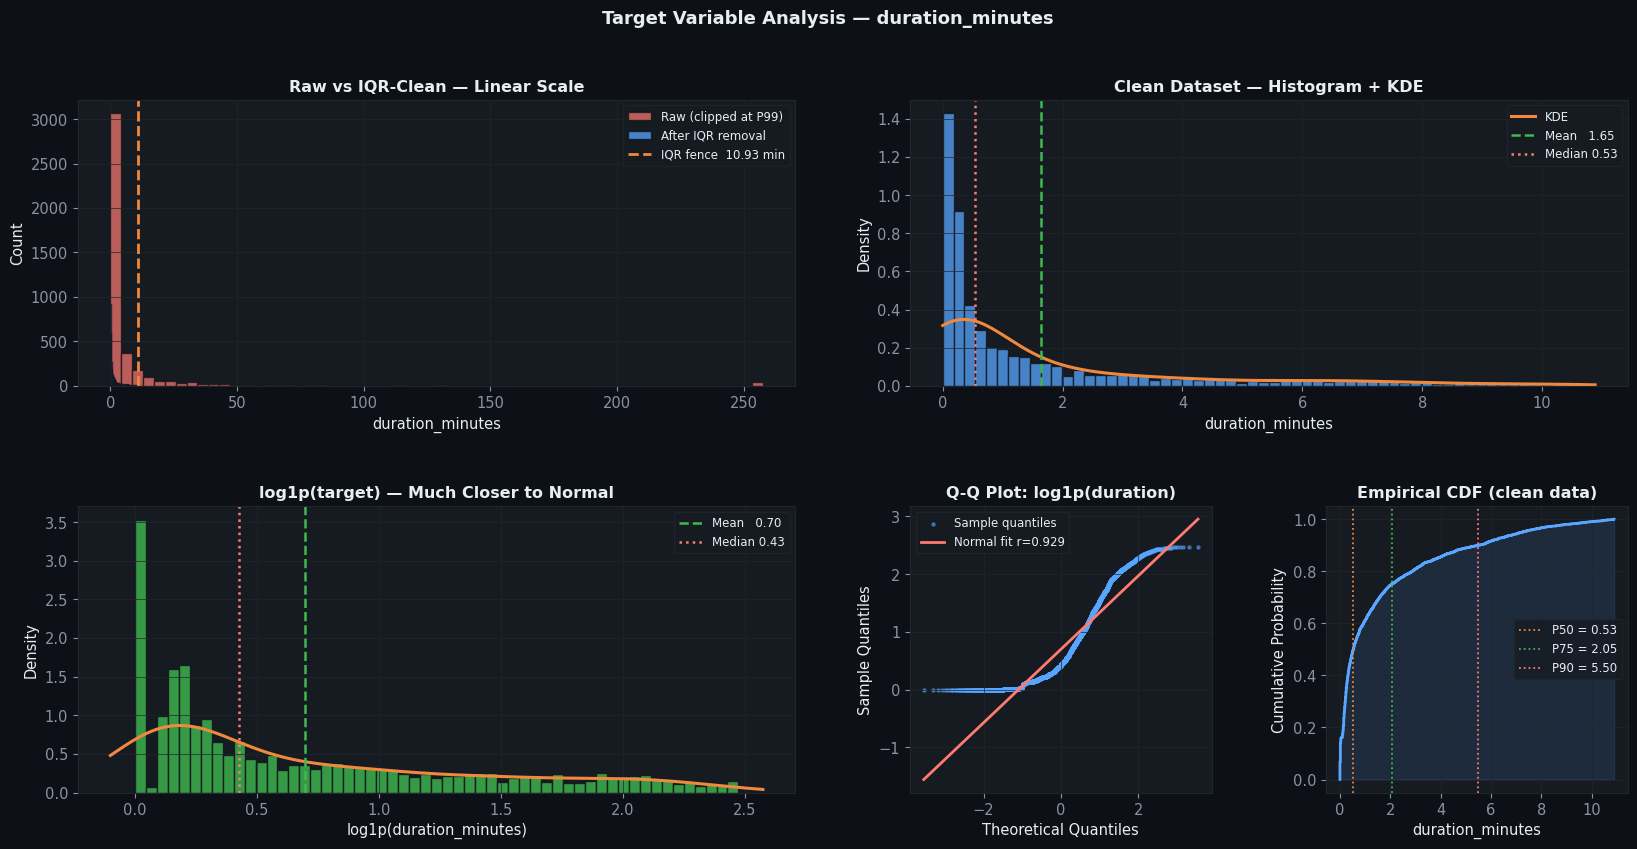

Normality tests (Shapiro-Wilk on 500-row sample):
  Raw target:        p = 0.00000  → NOT normal ✗
  log1p(target):     p = 0.00000  → NOT normal ✗
  log1p skewness   = 0.945  (raw = 1.903)

→ Use log1p-transformed target for training to stabilise variance.


In [3]:
fig = plt.figure(figsize=(20, 9))
fig.suptitle('Target Variable Analysis — duration_minutes')
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.42, wspace=0.38)

raw_t   = df_raw[TARGET]
clean_t = df[TARGET]
log_t   = np.log1p(clean_t)

# ── Raw vs Clean histogram ───────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0:2])
ax.hist(raw_t.clip(upper=raw_t.quantile(0.99)), bins=60,
        color=C[3], alpha=0.7, edgecolor=BG, label='Raw (clipped at P99)')
ax.hist(clean_t, bins=60, color=C[0], alpha=0.75, edgecolor=BG, label='After IQR removal')
ax.axvline(hi, color=C[1], lw=2, ls='--', label=f'IQR fence  {hi:.2f} min')
ax.set_xlabel('duration_minutes'); ax.set_ylabel('Count')
ax.set_title('Raw vs IQR-Clean — Linear Scale')
ax.legend(fontsize=8.5)

# ── Clean KDE + box overlay ──────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2:4])
ax.hist(clean_t, bins=60, color=C[0], alpha=0.75, edgecolor=BG, density=True)
kde = stats.gaussian_kde(clean_t.clip(lower=0.001), bw_method=0.3)
xs  = np.linspace(0, clean_t.max(), 400)
ax.plot(xs, kde(xs), color=C[1], lw=2.2, label='KDE')
ax.axvline(clean_t.mean(),   color=C[2], lw=1.8, ls='--', label=f'Mean   {clean_t.mean():.2f}')
ax.axvline(clean_t.median(), color=C[3], lw=1.8, ls=':',  label=f'Median {clean_t.median():.2f}')
ax.set_xlabel('duration_minutes'); ax.set_ylabel('Density')
ax.set_title('Clean Dataset — Histogram + KDE'); ax.legend(fontsize=8.5)

# ── log1p transform histogram ────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0:2])
ax.hist(log_t, bins=55, color=C[2], alpha=0.80, edgecolor=BG, density=True)
kde_log = stats.gaussian_kde(log_t, bw_method=0.3)
xs_l    = np.linspace(log_t.min()-0.1, log_t.max()+0.1, 400)
ax.plot(xs_l, kde_log(xs_l), color=C[1], lw=2.2)
ax.axvline(log_t.mean(),   color=C[2], lw=1.8, ls='--', label=f'Mean   {log_t.mean():.2f}')
ax.axvline(log_t.median(), color=C[3], lw=1.8, ls=':',  label=f'Median {log_t.median():.2f}')
ax.set_xlabel('log1p(duration_minutes)'); ax.set_ylabel('Density')
ax.set_title('log1p(target) — Much Closer to Normal'); ax.legend(fontsize=8.5)

# ── Q-Q plot of log1p ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
(osm, osr), (slope, intercept, r_qq) = stats.probplot(log_t, dist='norm')
ax.scatter(osm, osr, color=C[0], s=5, alpha=0.5, label='Sample quantiles')
xl = np.linspace(min(osm), max(osm), 100)
ax.plot(xl, slope*xl + intercept, color=C[3], lw=2, label=f'Normal fit r={r_qq:.3f}')
ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Sample Quantiles')
ax.set_title('Q-Q Plot: log1p(duration)'); ax.legend(fontsize=8.5)

# ── ECDF ─────────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 3])
s  = np.sort(clean_t)
ax.step(s, np.arange(1,len(s)+1)/len(s), color=C[0], lw=2, where='post')
ax.fill_between(s, np.arange(1,len(s)+1)/len(s), alpha=0.12, color=C[0], step='post')
for p, col in [(0.50,C[1]),(0.75,C[2]),(0.90,C[3])]:
    v = np.quantile(clean_t, p)
    ax.axvline(v, color=col, lw=1.3, ls=':', label=f'P{int(p*100)} = {v:.2f}')
ax.set_xlabel('duration_minutes'); ax.set_ylabel('Cumulative Probability')
ax.set_title('Empirical CDF (clean data)'); ax.legend(fontsize=8.5)

plt.show()

stat_w, p_w   = shapiro(log_t.sample(min(500, len(log_t)), random_state=42))
stat_r, p_raw = shapiro(clean_t.sample(min(500, len(clean_t)), random_state=42))
print('Normality tests (Shapiro-Wilk on 500-row sample):')
print(f'  Raw target:        p = {p_raw:.5f}  → {"NOT normal ✗" if p_raw<0.05 else "Normal ✓"}')
print(f'  log1p(target):     p = {p_w:.5f}  → {"NOT normal ✗" if p_w<0.05 else "Normal ✓"}')
print(f'  log1p skewness   = {log_t.skew():.3f}  (raw = {clean_t.skew():.3f})')
print(f'\n→ Use log1p-transformed target for training to stabilise variance.')

---
## 3 · Feature Variance Audit

Only features with genuine variance can carry predictive signal. Zero-variance features are immediately dropped.

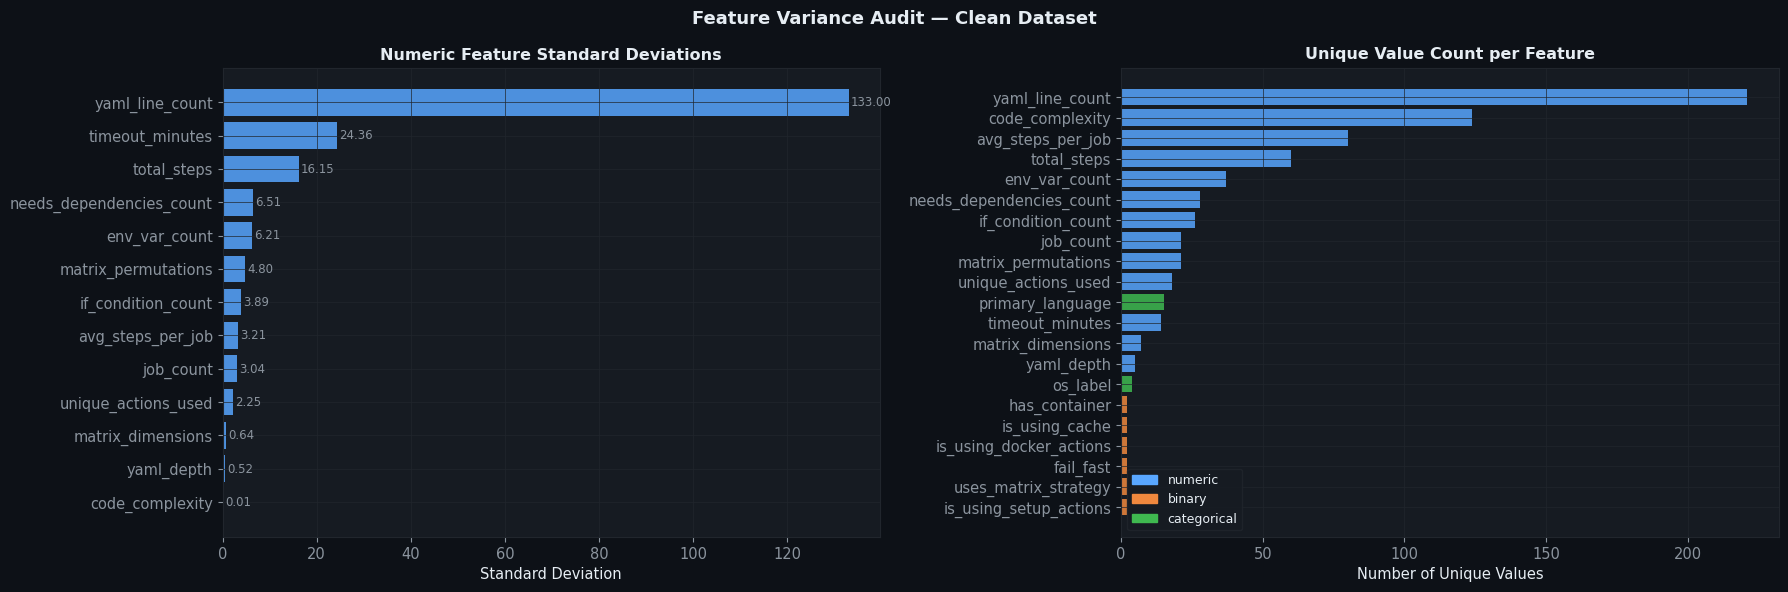

Zero-variance features: None — all features have variance ✓
Total usable candidate features: 21


In [4]:
# All candidate predictors (workflow_name excluded by design)
candidate_num = ['yaml_line_count','yaml_depth','job_count','total_steps',
                 'avg_steps_per_job','matrix_dimensions','matrix_permutations',
                 'timeout_minutes','unique_actions_used','env_var_count',
                 'if_condition_count','needs_dependencies_count','code_complexity']
candidate_bin = ['uses_matrix_strategy','fail_fast','is_using_setup_actions',
                 'is_using_docker_actions','is_using_cache','has_container']
candidate_cat = ['os_label','primary_language']

va_rows = []
for col in candidate_num + candidate_bin:
    s = df[col].std()
    va_rows.append({'Feature': col, 'Std Dev': round(s,4),
                    'Unique Values': df[col].nunique(),
                    'Type': 'numeric' if col in candidate_num else 'binary',
                    'Has Variance': s > 0})
for col in candidate_cat:
    va_rows.append({'Feature': col, 'Std Dev': np.nan,
                    'Unique Values': df[col].nunique(),
                    'Type': 'categorical', 'Has Variance': True})
var_df = pd.DataFrame(va_rows)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Feature Variance Audit — Clean Dataset')

# Std dev chart
ax = axes[0]
num_var = var_df[var_df['Type']=='numeric'].sort_values('Std Dev')
type_colors = {'numeric': C[0], 'binary': C[1], 'categorical': C[2]}
bar_c = [C[0]]*len(num_var)
ax.barh(num_var['Feature'], num_var['Std Dev'], color=bar_c, edgecolor='none', alpha=0.85)
ax.set_xlabel('Standard Deviation')
ax.set_title('Numeric Feature Standard Deviations')
for i, (_, row) in enumerate(num_var.iterrows()):
    ax.text(row['Std Dev']+0.5, i, f'{row["Std Dev"]:.2f}', va='center', fontsize=8.5, color=TICK)

# Unique value count — all features
ax = axes[1]
all_var = var_df.sort_values('Unique Values')
bar_c2 = [type_colors[t] for t in all_var['Type']]
ax.barh(all_var['Feature'], all_var['Unique Values'], color=bar_c2, edgecolor='none', alpha=0.85)
ax.set_xlabel('Number of Unique Values')
ax.set_title('Unique Value Count per Feature')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=type_colors[t], label=t) for t in ['numeric','binary','categorical']],
          fontsize=9)

plt.tight_layout(); plt.show()

zero_var = var_df[~var_df['Has Variance']]['Feature'].tolist()
print(f'Zero-variance features: {zero_var if zero_var else "None — all features have variance ✓"}')
print(f'Total usable candidate features: {len(var_df)}')

---
## 4 · Numeric Features — Distributions Coloured by Duration Quartile

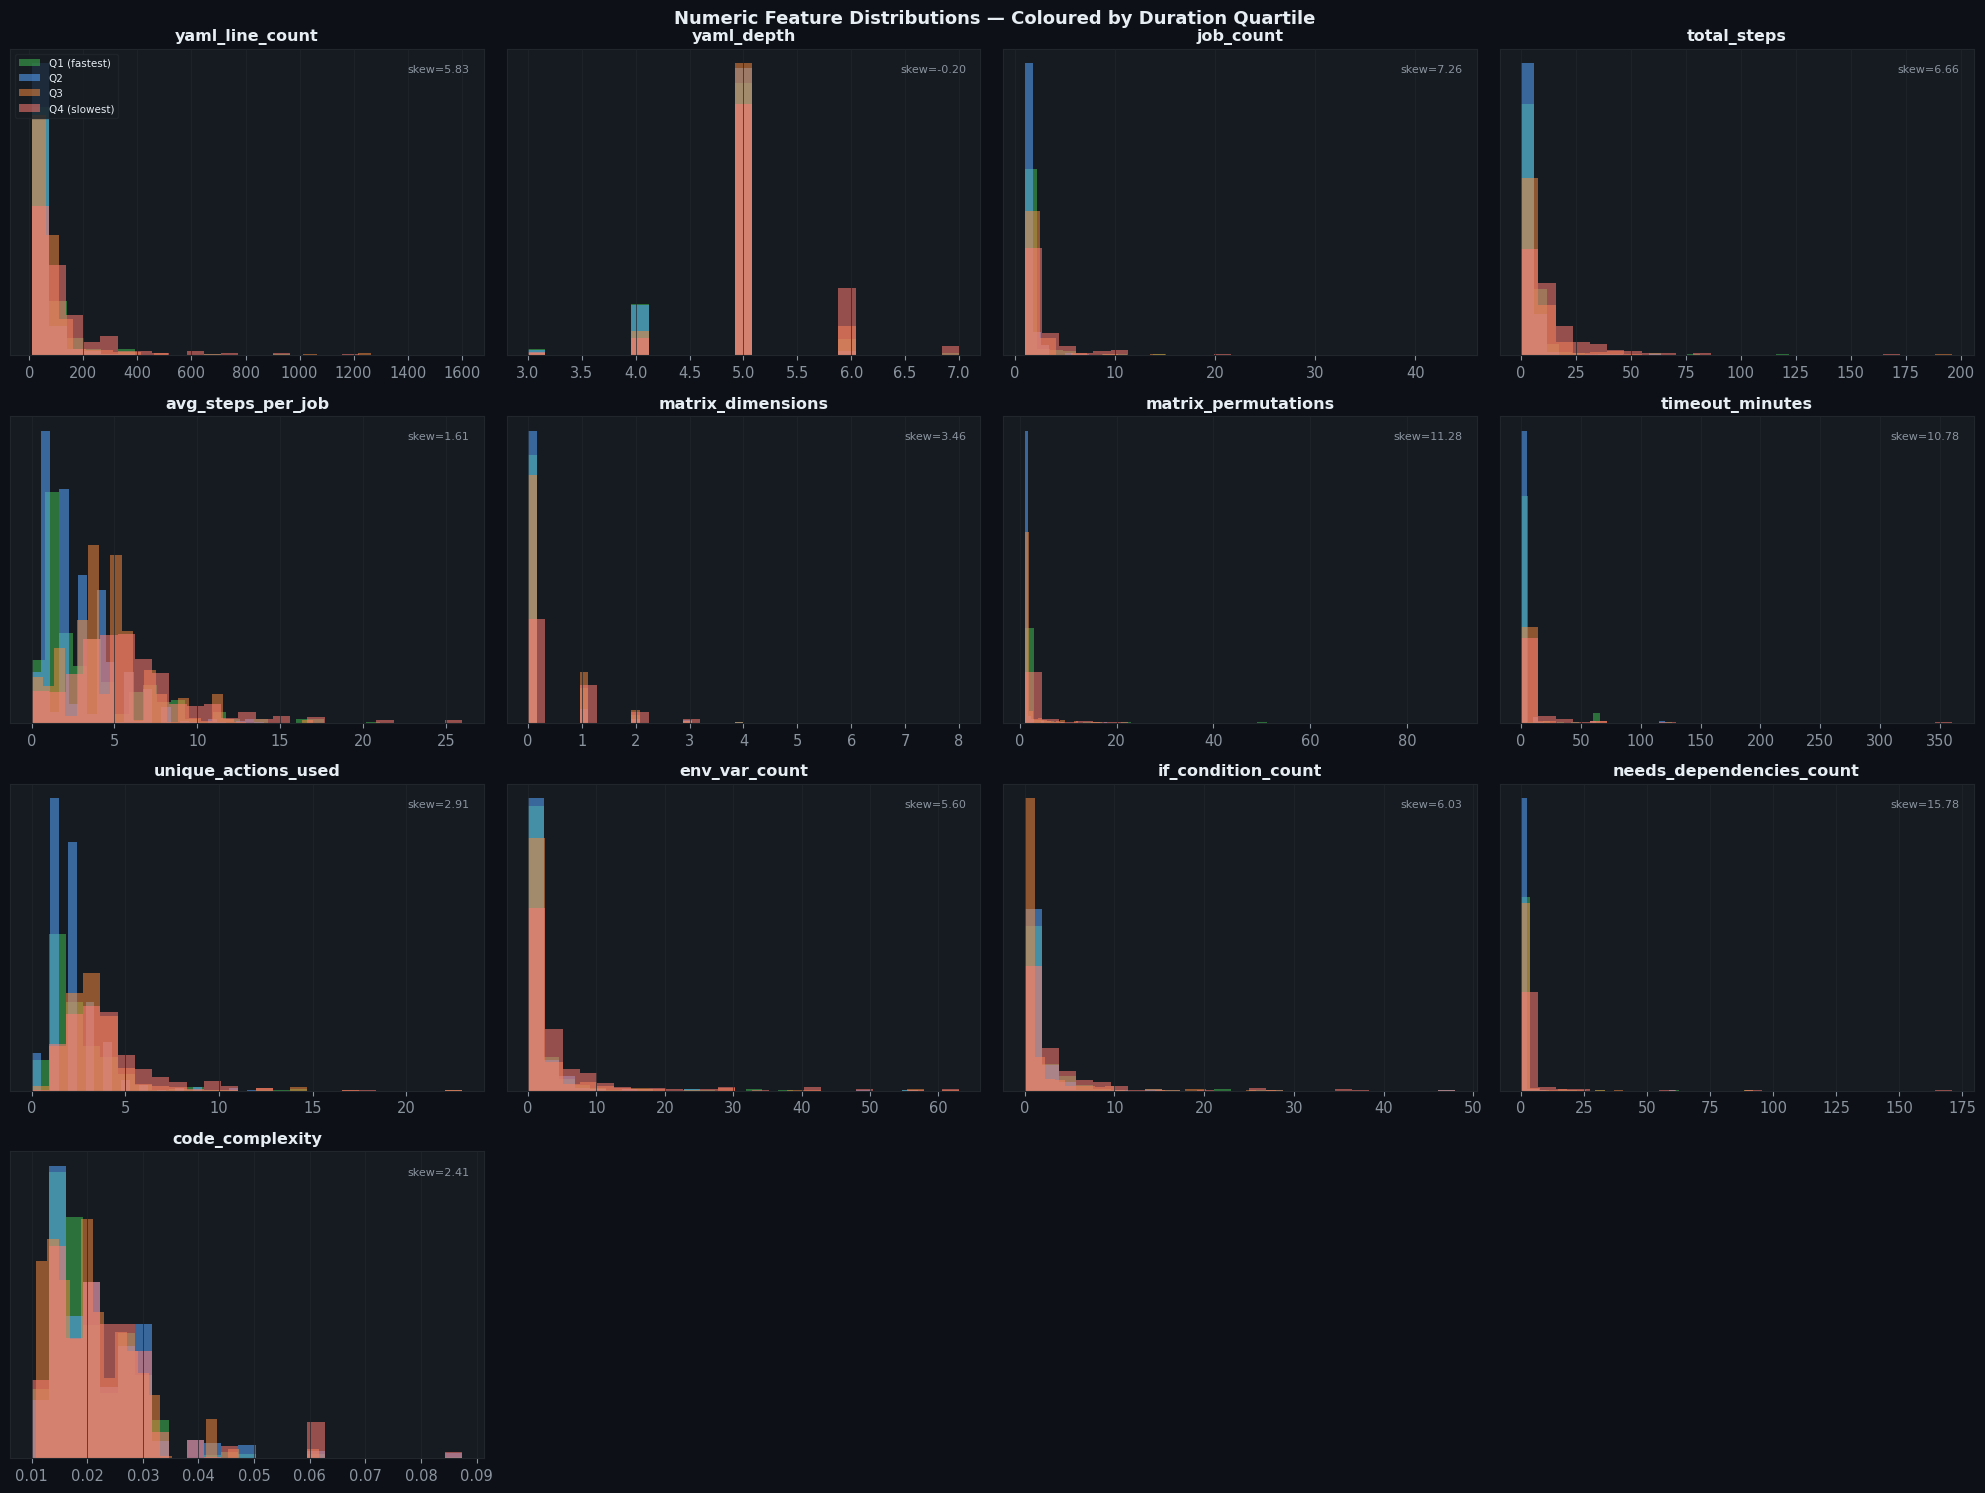

In [5]:
df['dur_quartile'] = pd.qcut(df[TARGET], q=4,
                              labels=['Q1 (fastest)','Q2','Q3','Q4 (slowest)'])
q_palette = dict(zip(['Q1 (fastest)','Q2','Q3','Q4 (slowest)'],
                     [C[2], C[0], C[1], C[3]]))

ncols = 4
nrows = -(-len(candidate_num) // ncols)   # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows*3.8))
fig.suptitle('Numeric Feature Distributions — Coloured by Duration Quartile')
axes = axes.flatten()

for i, col in enumerate(candidate_num):
    ax = axes[i]
    for label, color in q_palette.items():
        vals = df[df['dur_quartile']==label][col].dropna()
        ax.hist(vals, bins=25, alpha=0.55, color=color,
                edgecolor='none', density=True, label=label)
    ax.set_title(col); ax.set_xlabel(''); ax.set_yticks([])
    ax.text(0.97, 0.95, f'skew={df[col].skew():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8, color=TICK)
    if i == 0:
        ax.legend(fontsize=7.5, loc='upper left')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(); plt.show()

---
## 5 · Correlation Metrics: Every Feature vs `duration_minutes`

Pearson r, Spearman ρ, Kendall τ, and Mutual Information are computed for every usable feature against the clean target. Categorical features are ordinal-encoded by median duration to make them comparable.

In [6]:
y     = df[TARGET].values
log_y = np.log1p(y)

# Encode categoricals by median duration (preserves natural ordering)
for cat_col in candidate_cat:
    med_map = df.groupby(cat_col)[TARGET].median().to_dict()
    df[f'{cat_col}_enc'] = df[cat_col].map(med_map)

all_features = (candidate_num + candidate_bin +
                [f'{c}_enc' for c in candidate_cat])

corr_rows = []
for feat in all_features:
    x = df[feat].values.astype(float)
    if x.std() == 0:
        continue
    p_r, p_p = pearsonr(x, y)
    s_r, s_p = spearmanr(x, y)
    k_r, k_p = kendalltau(x, y)
    mi_raw   = mutual_info_regression(x.reshape(-1,1), y,      random_state=42)[0]
    mi_log   = mutual_info_regression(x.reshape(-1,1), log_y,  random_state=42)[0]
    display_name = feat.replace('_enc','')
    corr_rows.append({
        'Feature'    : display_name,
        'Pearson r'  : round(p_r, 4),
        'Pearson p'  : round(p_p, 4),
        'Spearman ρ' : round(s_r, 4),
        'Spearman p' : round(s_p, 4),
        'Kendall τ'  : round(k_r, 4),
        'Kendall p'  : round(k_p, 4),
        'MI (raw y)' : round(mi_raw, 5),
        'MI (log y)' : round(mi_log, 5),
    })

corr_df = pd.DataFrame(corr_rows)
corr_df['|Spearman|'] = corr_df['Spearman ρ'].abs()
corr_df['|Pearson|']  = corr_df['Pearson r'].abs()
corr_df['|Kendall|']  = corr_df['Kendall τ'].abs()
corr_df = corr_df.sort_values('|Spearman|', ascending=False).reset_index(drop=True)

display(corr_df[['Feature','Pearson r','Pearson p','Spearman ρ','Spearman p',
                  'Kendall τ','Kendall p','MI (raw y)','MI (log y)']]
        .style
        .background_gradient(cmap='RdBu_r', subset=['Pearson r','Spearman ρ','Kendall τ'], vmin=-1, vmax=1)
        .background_gradient(cmap='Blues', subset=['MI (raw y)','MI (log y)'])
        .applymap(lambda v: 'color: #3fb950; font-weight:bold' if isinstance(v,float) and v < 0.05
                  else ('color: #ff7b72' if isinstance(v,float) and v >= 0.05 else ''),
                  subset=['Pearson p','Spearman p','Kendall p'])
        .format({'Pearson r':'{:.4f}','Pearson p':'{:.4f}',
                 'Spearman ρ':'{:.4f}','Spearman p':'{:.4f}',
                 'Kendall τ':'{:.4f}', 'Kendall p':'{:.4f}',
                 'MI (raw y)':'{:.5f}','MI (log y)':'{:.5f}'}))

,Feature,Pearson r,Pearson p,Spearman ρ,Spearman p,Kendall τ,Kendall p,MI (raw y),MI (log y)
0,total_steps,0.2949,0.0000,0.4401,0.0000,0.3288,0.0000,0.41119,0.41876
1,unique_actions_used,0.3119,0.0000,0.3806,0.0000,0.2931,0.0000,0.23663,0.23838
2,is_using_setup_actions,0.2702,0.0000,0.3745,0.0000,0.3083,0.0000,0.13412,0.13323
3,avg_steps_per_job,0.3175,0.0000,0.3651,0.0000,0.2730,0.0000,0.41306,0.41814
4,yaml_line_count,0.2481,0.0000,0.3124,0.0000,0.2238,0.0000,0.50609,0.42906
5,job_count,0.2034,0.0000,0.2789,0.0000,0.2200,0.0000,0.11296,0.11414
6,uses_matrix_strategy,0.2922,0.0000,0.2541,0.0000,0.2092,0.0000,0.06783,0.06668
7,yaml_depth,0.2372,0.0000,0.2333,0.0000,0.1890,0.0000,0.08063,0.08021
8,needs_dependencies_count,0.1036,0.0000,0.2296,0.0000,0.1847,0.0000,0.06598,0.06580
9,env_var_count,0.1949,0.0000,0.2271,0.0000,0.1707,0.0000,0.14543,0.14748


---
## 6 · Correlation Visualisation — Grouped Bar & Mutual Information

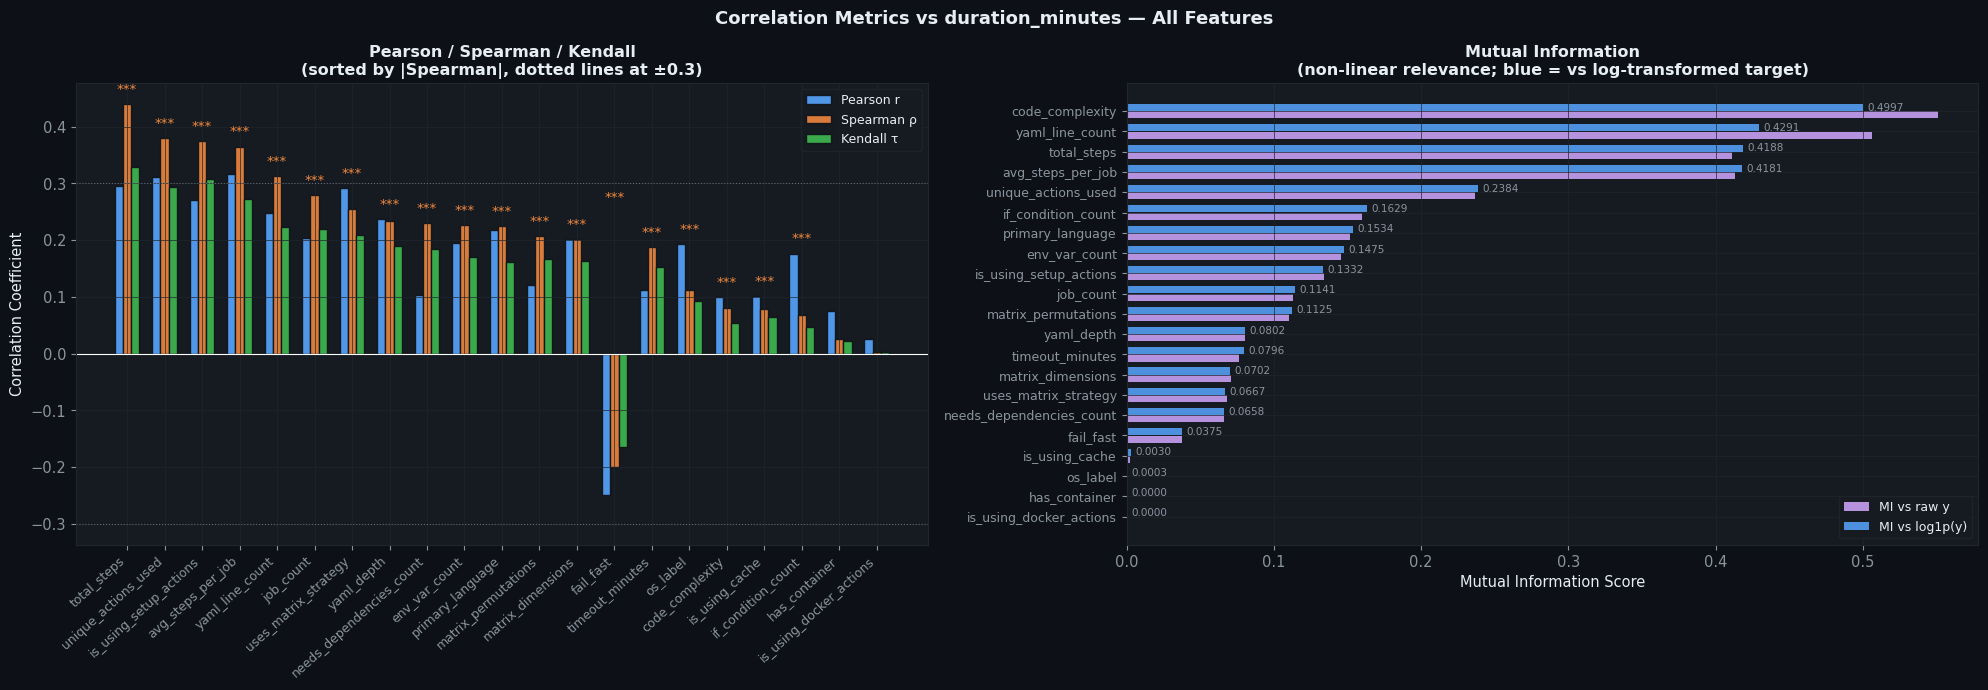

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Correlation Metrics vs duration_minutes — All Features')

feat_labels = corr_df['Feature'].tolist()
x_idx = np.arange(len(feat_labels))
w     = 0.22

# ── Grouped bar: Pearson / Spearman / Kendall ────────────────────────────
ax = axes[0]
ax.bar(x_idx - w, corr_df['Pearson r'],  w, label='Pearson r',  color=C[0], alpha=0.9, edgecolor=BG)
ax.bar(x_idx,     corr_df['Spearman ρ'], w, label='Spearman ρ', color=C[1], alpha=0.9, edgecolor=BG)
ax.bar(x_idx + w, corr_df['Kendall τ'],  w, label='Kendall τ',  color=C[2], alpha=0.9, edgecolor=BG)
ax.axhline(0, color='white', lw=0.8)
ax.axhline( 0.3, color=TICK, lw=0.8, ls=':', alpha=0.6)
ax.axhline(-0.3, color=TICK, lw=0.8, ls=':', alpha=0.6)
ax.set_xticks(x_idx)
ax.set_xticklabels(feat_labels, rotation=42, ha='right', fontsize=9)
ax.set_ylabel('Correlation Coefficient')
ax.set_title('Pearson / Spearman / Kendall\n(sorted by |Spearman|, dotted lines at ±0.3)')
ax.legend(fontsize=9)
# Significance annotation
for i, (_, row) in enumerate(corr_df.iterrows()):
    star = ('***' if row['Spearman p']<0.001 else
            '**'  if row['Spearman p']<0.01  else
            '*'   if row['Spearman p']<0.05  else '')
    if star:
        ypos = max(abs(row['Pearson r']),abs(row['Spearman ρ']),abs(row['Kendall τ'])) + 0.02
        ax.text(i, ypos, star, ha='center', fontsize=9.5, color=C[1])

# ── Mutual Information — dual bar (raw vs log y) ──────────────────────────
ax = axes[1]
mi_sorted = corr_df.sort_values('MI (log y)', ascending=True)
y_pos = np.arange(len(mi_sorted))
ax.barh(y_pos - 0.18, mi_sorted['MI (raw y)'],  0.35, color=C[4], alpha=0.85,
        edgecolor='none', label='MI vs raw y')
ax.barh(y_pos + 0.18, mi_sorted['MI (log y)'],  0.35, color=C[0], alpha=0.85,
        edgecolor='none', label='MI vs log1p(y)')
ax.set_yticks(y_pos)
ax.set_yticklabels(mi_sorted['Feature'], fontsize=9)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Mutual Information\n(non-linear relevance; blue = vs log-transformed target)')
ax.legend(fontsize=9)
for i, (_, row) in enumerate(mi_sorted.iterrows()):
    ax.text(row['MI (log y)']+0.003, i+0.18, f'{row["MI (log y)"]:.4f}',
            va='center', fontsize=7.5, color=TICK)

plt.tight_layout(); plt.show()

---
## 7 · Non-Linearity Diagnostic — Pearson vs Spearman Divergence

Features **above** the y=x line have stronger rank correlation than linear correlation, indicating a **monotonic but non-linear** relationship that tree-based models will capture better than linear regression.

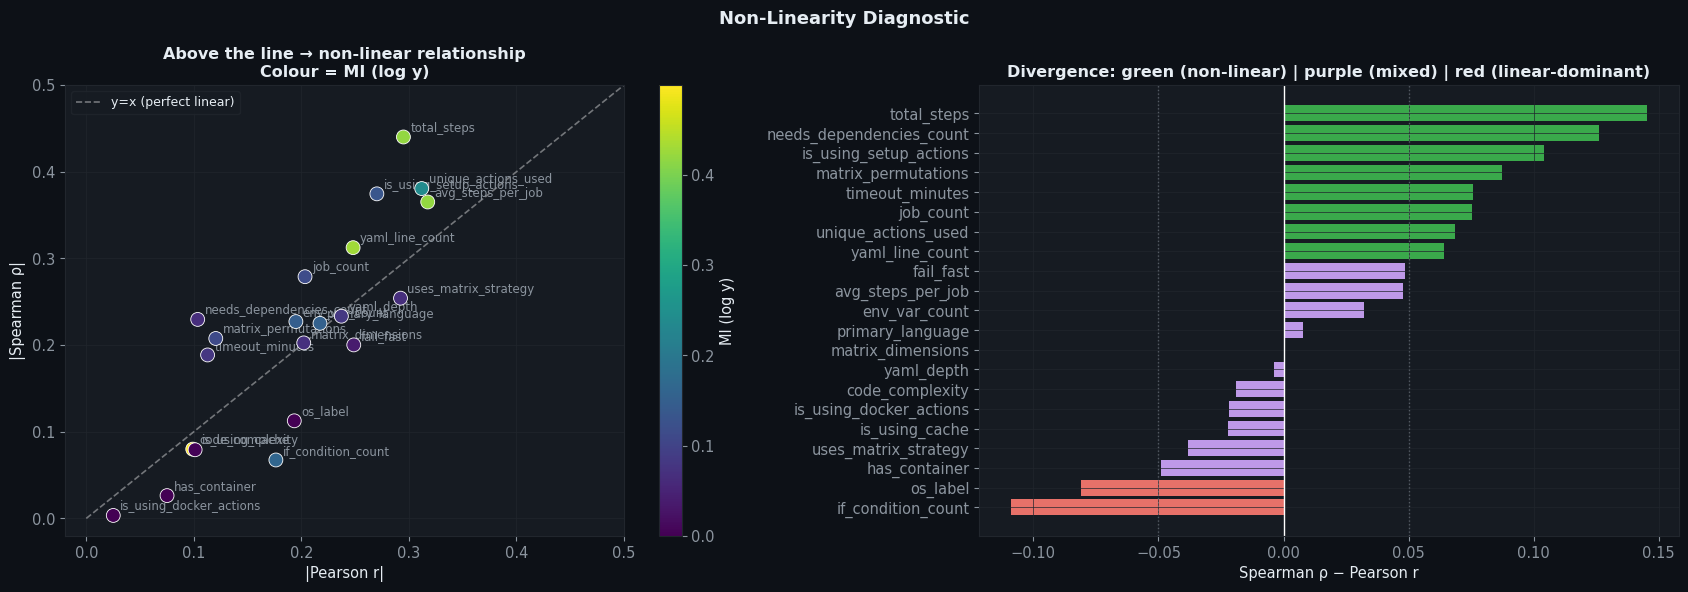

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Non-Linearity Diagnostic')

# Scatter: |Pearson| vs |Spearman|
ax = axes[0]
px = corr_df['|Pearson|'].values
sy = corr_df['|Spearman|'].values
sc = ax.scatter(px, sy, s=100, c=corr_df['MI (log y)'].values,
                cmap=CMAP_SEQ, edgecolors='white', lw=0.6, zorder=4)
plt.colorbar(sc, ax=ax, label='MI (log y)')
for _, row in corr_df.iterrows():
    ax.annotate(row['Feature'], (row['|Pearson|'], row['|Spearman|']),
                textcoords='offset points', xytext=(5,4), fontsize=8.5, color=TICK)
lim = max(px.max(), sy.max()) + 0.06
ax.plot([0,lim],[0,lim], 'w--', lw=1.2, alpha=0.4, label='y=x (perfect linear)')
ax.set_xlim(-0.02, lim); ax.set_ylim(-0.02, lim)
ax.set_xlabel('|Pearson r|')
ax.set_ylabel('|Spearman ρ|')
ax.set_title('Above the line → non-linear relationship\nColour = MI (log y)')
ax.legend(fontsize=9)

# Divergence bar: Spearman − Pearson (signed)
ax = axes[1]
corr_df['Divergence'] = corr_df['Spearman ρ'] - corr_df['Pearson r']
div_s = corr_df.sort_values('Divergence')
div_c = [C[2] if v > 0.05 else (C[3] if v < -0.05 else C[4]) for v in div_s['Divergence']]
ax.barh(div_s['Feature'], div_s['Divergence'], color=div_c, edgecolor='none', alpha=0.9)
ax.axvline(0, color='white', lw=1)
ax.axvline( 0.05, color=TICK, lw=1, ls=':', alpha=0.5)
ax.axvline(-0.05, color=TICK, lw=1, ls=':', alpha=0.5)
ax.set_xlabel('Spearman ρ − Pearson r')
ax.set_title('Divergence: green (non-linear) | purple (mixed) | red (linear-dominant)')

plt.tight_layout(); plt.show()

---
## 8 · Top Numeric Features — Scatter vs Duration with LOWESS

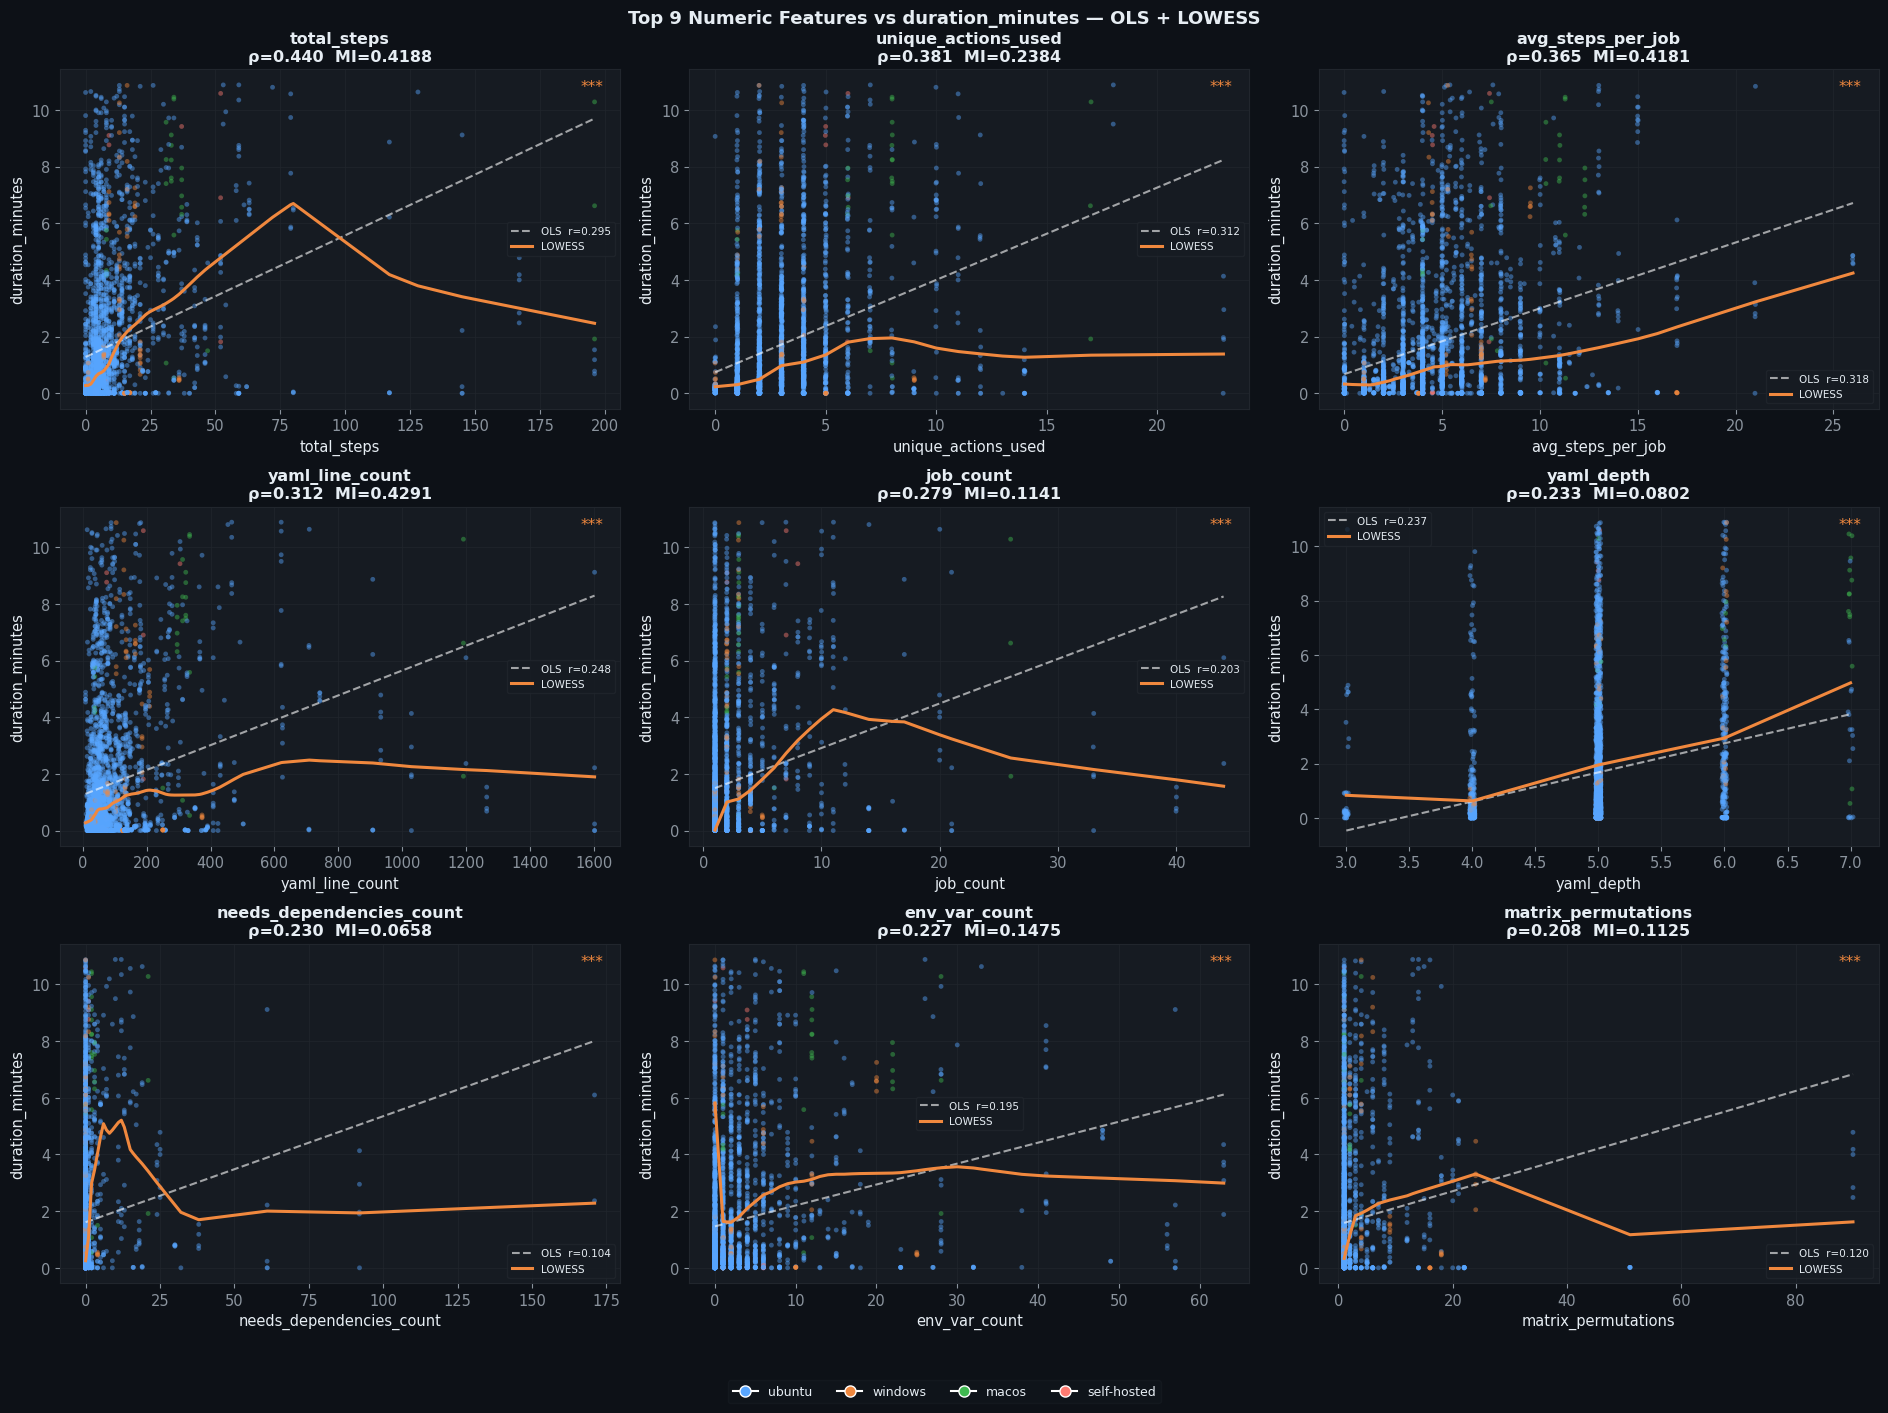

In [9]:
from statsmodels.nonparametric.smoothers_lowess import lowess

top_num = (corr_df[corr_df['Feature'].isin(candidate_num)]
           .nlargest(9, '|Spearman|')['Feature'].tolist())

fig, axes = plt.subplots(3, 3, figsize=(19, 14))
fig.suptitle('Top 9 Numeric Features vs duration_minutes — OLS + LOWESS')
axes = axes.flatten()

# Colour by OS runner
os_color_map = {'ubuntu': C[0], 'windows': C[1], 'macos': C[2], 'self-hosted': C[3]}
dot_c = [os_color_map.get(v, C[4]) for v in df['os_label']]

for i, feat in enumerate(top_num):
    ax = axes[i]
    x  = df[feat].values.astype(float)
    y2 = df[TARGET].values

    ax.scatter(x + np.random.uniform(-0.02,0.02,len(x)), y2,
               c=dot_c, s=12, alpha=0.45, edgecolors='none', zorder=2)

    if x.std() > 0:
        m, b, r, p_val, _ = stats.linregress(x, y2)
        xs  = np.linspace(x.min(), x.max(), 200)
        ax.plot(xs, m*xs+b, color='white', lw=1.5, ls='--', alpha=0.6,
                label=f'OLS  r={r:.3f}')
        lo_out = lowess(y2, x, frac=0.4, return_sorted=True)
        ax.plot(lo_out[:,0], lo_out[:,1], color=C[1], lw=2.2, label='LOWESS')
        star = ('***' if p_val<0.001 else '**' if p_val<0.01
                else '*' if p_val<0.05 else 'ns')
        ax.text(0.97,0.97,star, transform=ax.transAxes,
                ha='right', va='top', fontsize=11, color=C[1])
        ax.legend(fontsize=7.5)

    spear_val = corr_df.loc[corr_df['Feature']==feat,'Spearman ρ'].values
    mi_val    = corr_df.loc[corr_df['Feature']==feat,'MI (log y)'].values
    subtitle  = (f'ρ={spear_val[0]:.3f}  MI={mi_val[0]:.4f}'
                 if len(spear_val) else '')
    ax.set_xlabel(feat); ax.set_ylabel('duration_minutes')
    ax.set_title(f'{feat}\n{subtitle}')

# OS legend
from matplotlib.lines import Line2D
handles = [Line2D([0],[0],marker='o',color='w',markerfacecolor=c,ms=8,label=os)
           for os,c in os_color_map.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
           framealpha=0.3, bbox_to_anchor=(0.5,-0.02))

plt.tight_layout()
plt.subplots_adjust(bottom=0.07)
plt.show()

---
## 9 · Categorical Features — Duration Effect with Statistical Tests

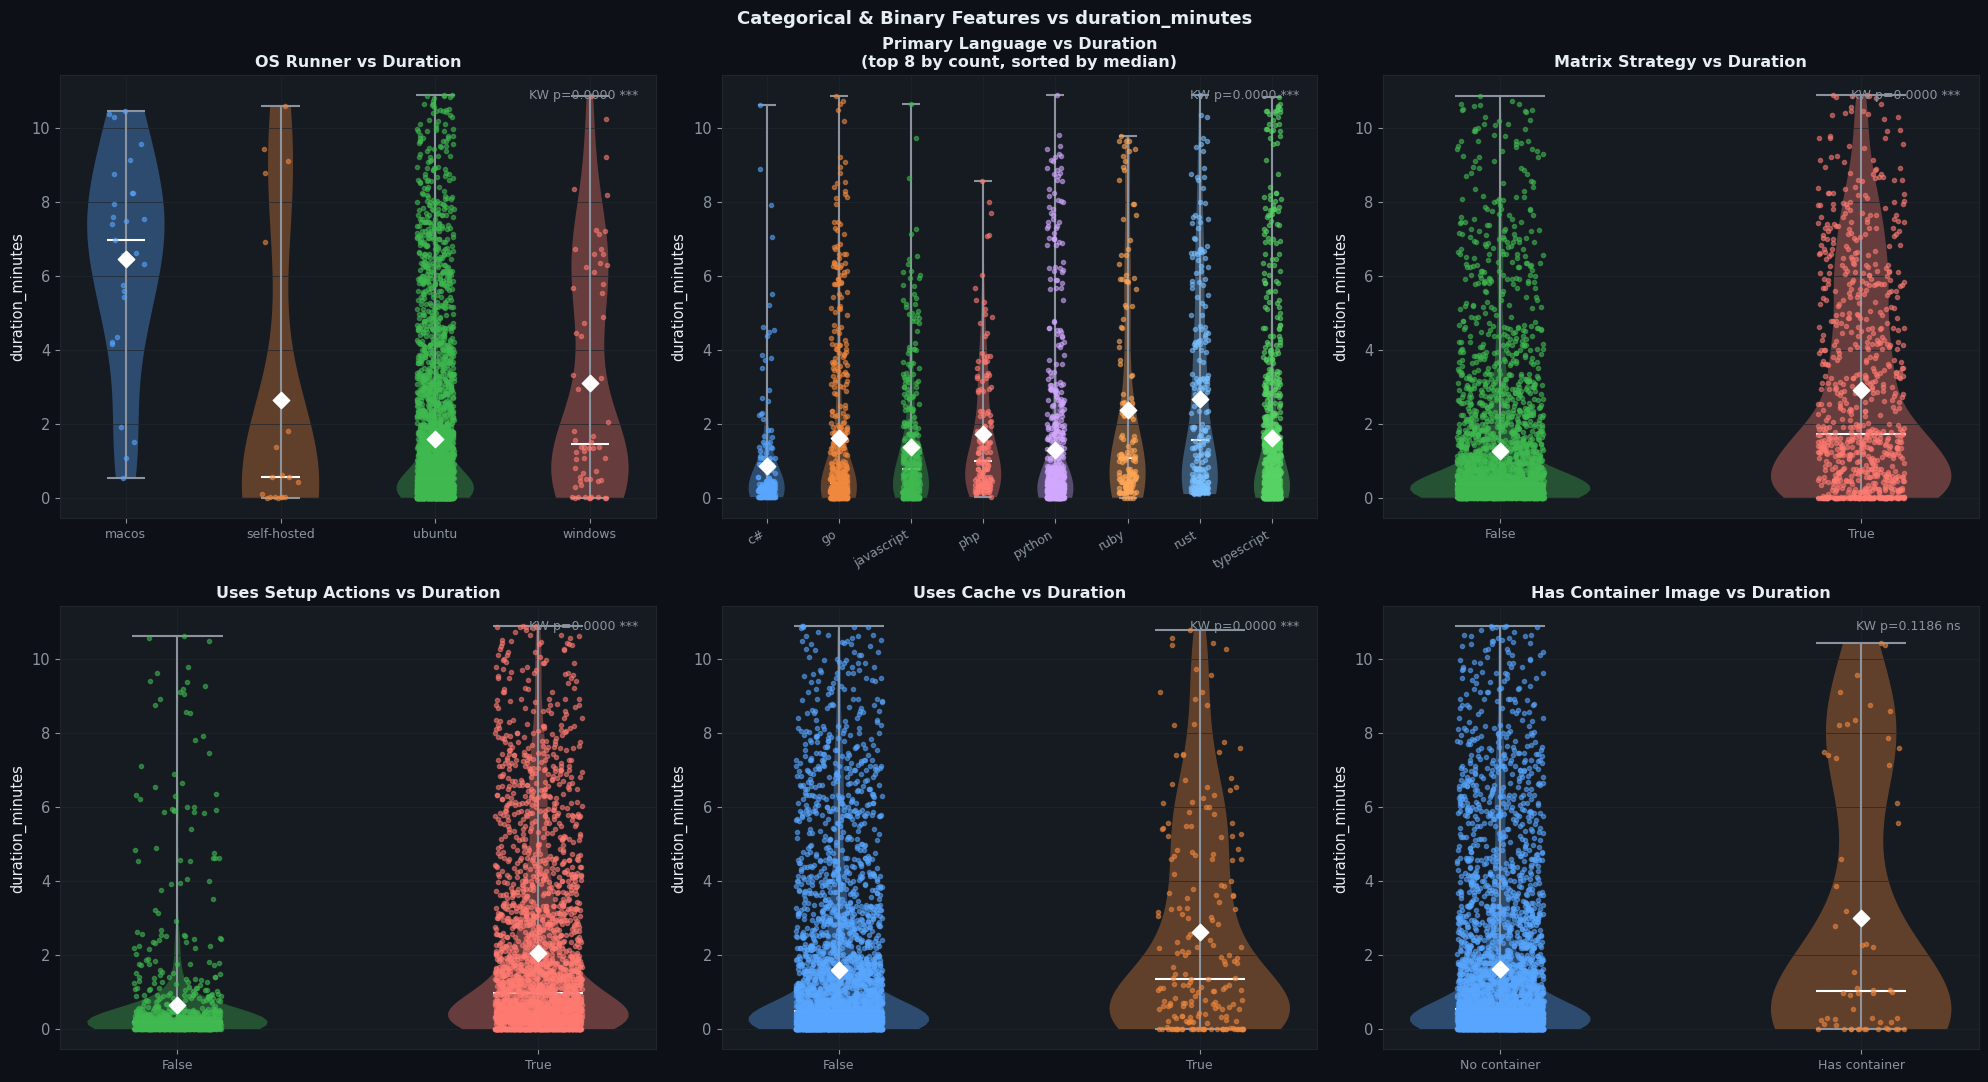

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Categorical & Binary Features vs duration_minutes')
axes = axes.flatten()

def violin_strip(ax, df, col, target_col, palette, title, rotate=False, label_map=None):
    groups = sorted(df[col].unique())
    data   = [df[df[col]==g][target_col].values for g in groups]
    labels = [label_map.get(str(g), str(g)) if label_map else str(g) for g in groups]

    if all(len(d)>1 for d in data):
        parts = ax.violinplot(data, positions=range(len(groups)), showmedians=True)
        for j, pc in enumerate(parts['bodies']):
            pc.set_facecolor(palette[j % len(palette)]); pc.set_alpha(0.35)
        parts['cmedians'].set_color('white')
        for k in ('cmins','cmaxes','cbars'):
            parts[k].set_color(TICK)

    for j, (grp, col_c) in enumerate(zip(data, palette)):
        jit = np.random.uniform(-0.12, 0.12, len(grp))
        ax.scatter(np.full(len(grp),j)+jit, grp, color=col_c,
                   s=9, alpha=0.55, zorder=3)
        ax.scatter(j, np.mean(grp), color='white', s=70, zorder=5, marker='D')

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(labels, rotation=30 if rotate else 0, ha='right' if rotate else 'center',
                       fontsize=9)
    ax.set_ylabel('duration_minutes')
    ax.set_title(title)

    if len(data) >= 2 and all(len(d)>=2 for d in data):
        stat_kw, p_kw = kruskal(*data)
        sig = ('***' if p_kw<0.001 else '**' if p_kw<0.01
               else '*' if p_kw<0.05 else 'ns')
        ax.text(0.97, 0.97, f'KW p={p_kw:.4f} {sig}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=9, color=TICK)
    return ax

# OS label
violin_strip(axes[0], df, 'os_label', TARGET, C,
             'OS Runner vs Duration', rotate=False)

# primary_language (top 8 by count)
top_langs = df['primary_language'].value_counts().head(8).index.tolist()
df_lang   = df[df['primary_language'].isin(top_langs)]
# Sort by median duration
lang_order = (df_lang.groupby('primary_language')[TARGET].median()
              .sort_values(ascending=False).index.tolist())
df_lang_sorted = df_lang.copy()
df_lang_sorted['primary_language'] = pd.Categorical(
    df_lang['primary_language'], categories=lang_order, ordered=True)
df_lang_sorted = df_lang_sorted.sort_values('primary_language')
violin_strip(axes[1], df_lang_sorted, 'primary_language', TARGET, C,
             'Primary Language vs Duration\n(top 8 by count, sorted by median)', rotate=True)

# uses_matrix_strategy
violin_strip(axes[2], df, 'uses_matrix_strategy', TARGET,
             [C[2],C[3]], 'Matrix Strategy vs Duration',
             label_map={'0':'False','1':'True'})

# is_using_setup_actions
violin_strip(axes[3], df, 'is_using_setup_actions', TARGET,
             [C[2],C[3]], 'Uses Setup Actions vs Duration',
             label_map={'0':'False','1':'True'})

# is_using_cache
violin_strip(axes[4], df, 'is_using_cache', TARGET,
             [C[0],C[1]], 'Uses Cache vs Duration',
             label_map={'0':'False','1':'True'})

# has_container
violin_strip(axes[5], df, 'has_container', TARGET,
             [C[0],C[1]], 'Has Container Image vs Duration',
             label_map={'0':'No container','1':'Has container'})

plt.tight_layout(); plt.show()

---
## 10 · OS Runner Effect — Mean Duration with 95% CI

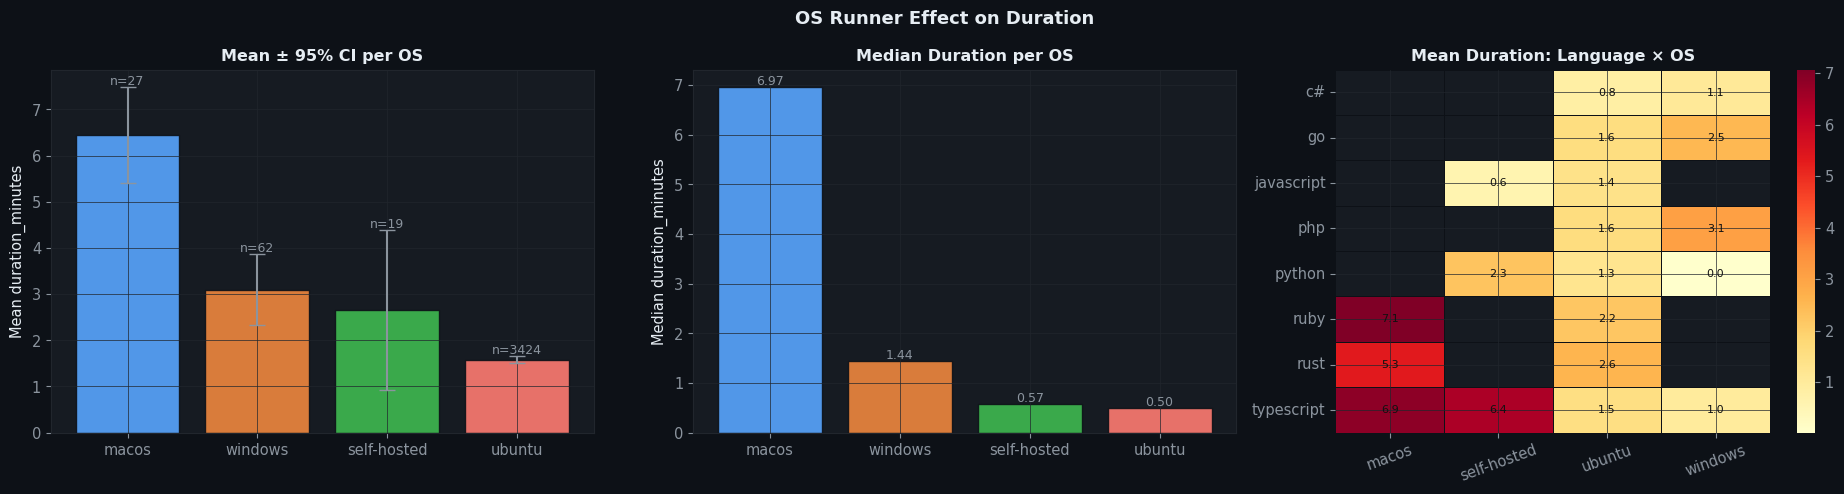

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle('OS Runner Effect on Duration')

os_order = (df.groupby('os_label')[TARGET].mean()
             .sort_values(ascending=False).index.tolist())

# Mean + 95% CI bar
ax = axes[0]
means, cis, ns = [], [], []
for os in os_order:
    sub = df[df['os_label']==os][TARGET].values
    means.append(sub.mean())
    cis.append(1.96*sub.std()/np.sqrt(len(sub)))
    ns.append(len(sub))
bars = ax.bar(range(len(os_order)), means,
              color=C[:len(os_order)], edgecolor=BG, alpha=0.9,
              yerr=cis, error_kw={'ecolor':TICK,'lw':1.5,'capsize':6})
ax.set_xticks(range(len(os_order)))
ax.set_xticklabels(os_order)
ax.set_ylabel('Mean duration_minutes')
ax.set_title('Mean ± 95% CI per OS')
for i,(m,n) in enumerate(zip(means,ns)):
    ax.text(i, m+cis[i]+0.05, f'n={n}', ha='center', fontsize=9, color=TICK)

# Median duration by OS
ax = axes[1]
medians = [df[df['os_label']==os][TARGET].median() for os in os_order]
ax.bar(range(len(os_order)), medians, color=C[:len(os_order)], edgecolor=BG, alpha=0.9)
ax.set_xticks(range(len(os_order)))
ax.set_xticklabels(os_order)
ax.set_ylabel('Median duration_minutes')
ax.set_title('Median Duration per OS')
for i,m in enumerate(medians):
    ax.text(i, m+0.05, f'{m:.2f}', ha='center', fontsize=9, color=TICK)

# OS × language heatmap (mean duration)
ax = axes[2]
pivot = df[df['primary_language'].isin(top_langs)].pivot_table(
    values=TARGET, index='primary_language', columns='os_label', aggfunc='mean')
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.4, linecolor=BG, annot_kws={'size':8,'color':'#111'})
ax.set_title('Mean Duration: Language × OS')
ax.set_xlabel(''); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout(); plt.show()

---
## 11 · Full Correlation Heatmap (Spearman)

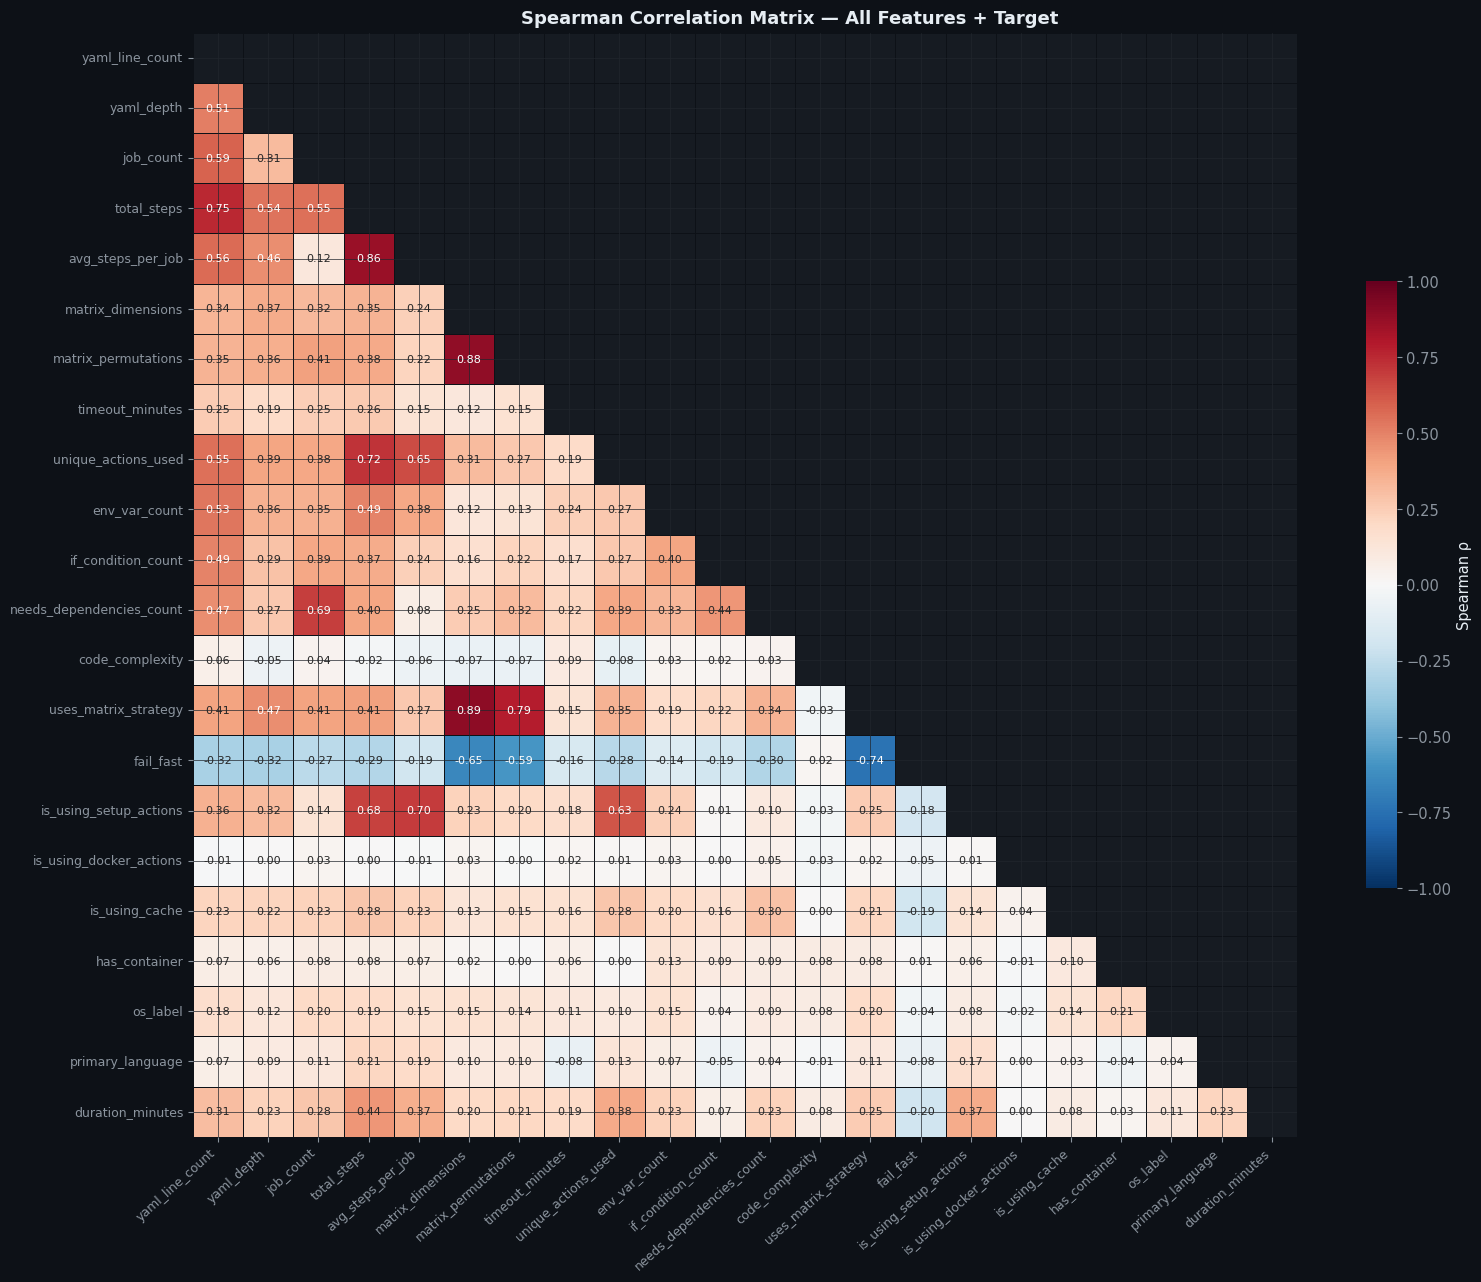

In [12]:
hmap_cols = [c for c in all_features if df[c].std()>0] + [TARGET]
hmap_df   = df[hmap_cols].astype(float)
corr_mat  = hmap_df.corr(method='spearman')

# Clean column names for display
rename = {c: c.replace('_enc','') for c in hmap_cols}
corr_mat = corr_mat.rename(index=rename, columns=rename)

fig, ax = plt.subplots(figsize=(16, 13))
fig.suptitle('Spearman Correlation Matrix — All Features + Target')

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat, ax=ax, mask=mask,
    cmap=CMAP_DIV, center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.4, linecolor=BG, square=True,
    cbar_kws={'shrink': 0.55, 'label': 'Spearman ρ'}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=42, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout(); plt.show()

---
## 12 · Multicollinearity — VIF Analysis

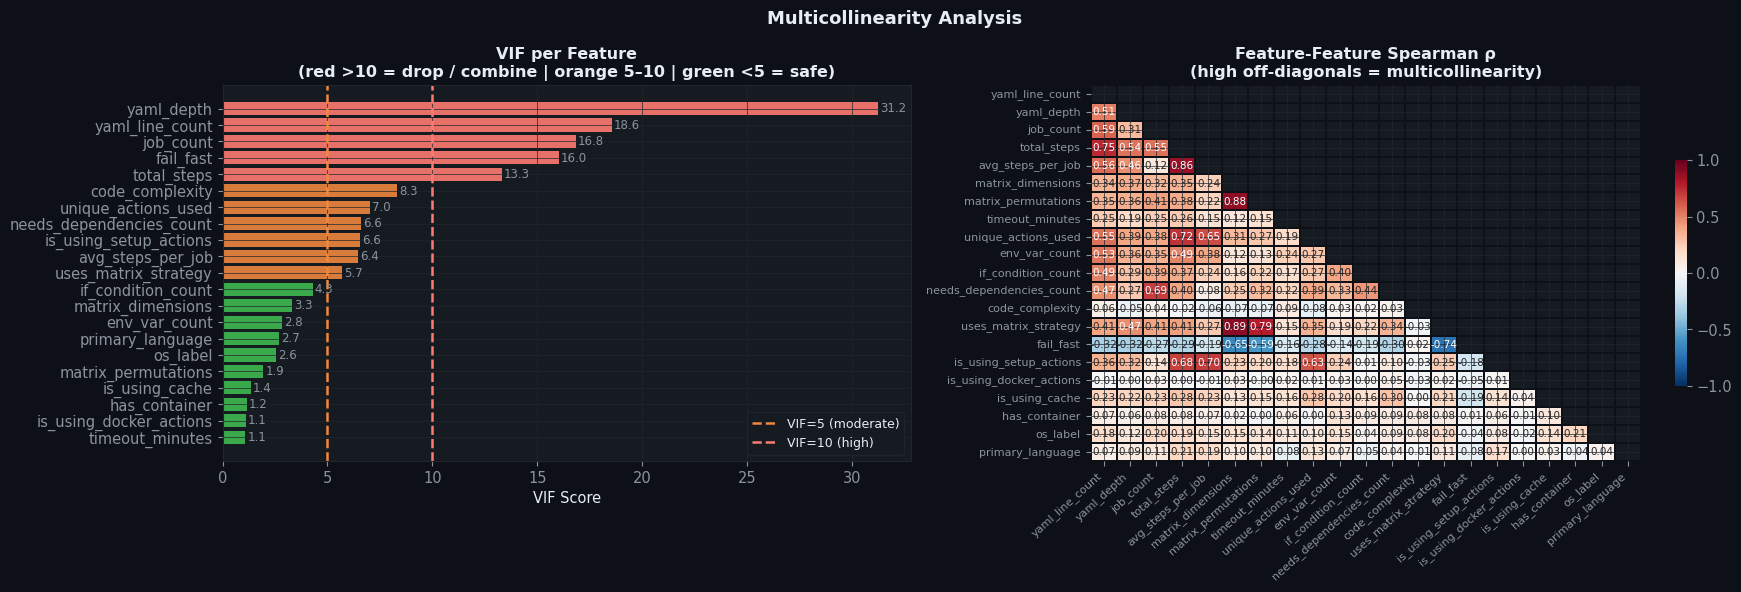

Features with VIF > 10 (strongly collinear — drop or aggregate):
   yaml_depth                          VIF = 31.2
   yaml_line_count                     VIF = 18.6
   job_count                           VIF = 16.8
   fail_fast                           VIF = 16.0
   total_steps                         VIF = 13.3


In [13]:
vif_cols = [c for c in all_features if df[c].std()>0]
X_vif    = df[vif_cols].astype(float)

vif_vals = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_df   = (pd.DataFrame({'Feature': [c.replace('_enc','') for c in vif_cols],
                          'VIF': vif_vals})
            .sort_values('VIF', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Multicollinearity Analysis')

# VIF bar
ax = axes[0]
vif_c = ['#ff7b72' if v>10 else '#f0883e' if v>5 else '#3fb950' for v in vif_df['VIF']]
ax.barh(vif_df['Feature'][::-1], vif_df['VIF'][::-1], color=vif_c[::-1], edgecolor='none', alpha=0.9)
ax.axvline(5,  color=C[1], lw=1.8, ls='--', label='VIF=5 (moderate)')
ax.axvline(10, color=C[3], lw=1.8, ls='--', label='VIF=10 (high)')
ax.set_xlabel('VIF Score')
ax.set_title('VIF per Feature\n(red >10 = drop / combine | orange 5–10 | green <5 = safe)')
ax.legend(fontsize=9)
for i,(_, row) in enumerate(vif_df[::-1].iterrows()):
    ax.text(row['VIF']+0.1, i, f'{row["VIF"]:.1f}', va='center', fontsize=8.5, color=TICK)

# Collinear pair heatmap (only feature-vs-feature, |ρ|>0.5)
ax = axes[1]
feat_corr = X_vif.corr(method='spearman').rename(
    columns=rename, index=rename)
high_mask  = feat_corr.abs() < 0.5
high_mask |= np.eye(len(feat_corr), dtype=bool)  # keep diagonal
masked = feat_corr.where(~high_mask)
sns.heatmap(feat_corr, ax=ax, cmap=CMAP_DIV, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':7.5},
            linewidths=0.3, linecolor=BG, mask=np.triu(np.ones_like(feat_corr,dtype=bool)),
            cbar_kws={'shrink':0.6})
ax.set_xticklabels(ax.get_xticklabels(), rotation=42, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
ax.set_title('Feature-Feature Spearman ρ\n(high off-diagonals = multicollinearity)')

plt.tight_layout(); plt.show()

high_vif = vif_df[vif_df['VIF']>10]
print('Features with VIF > 10 (strongly collinear — drop or aggregate):')
for _, r in high_vif.iterrows():
    print(f'   {r["Feature"]:<35} VIF = {r["VIF"]:.1f}')

---
## 13 · Random Forest Feature Importance

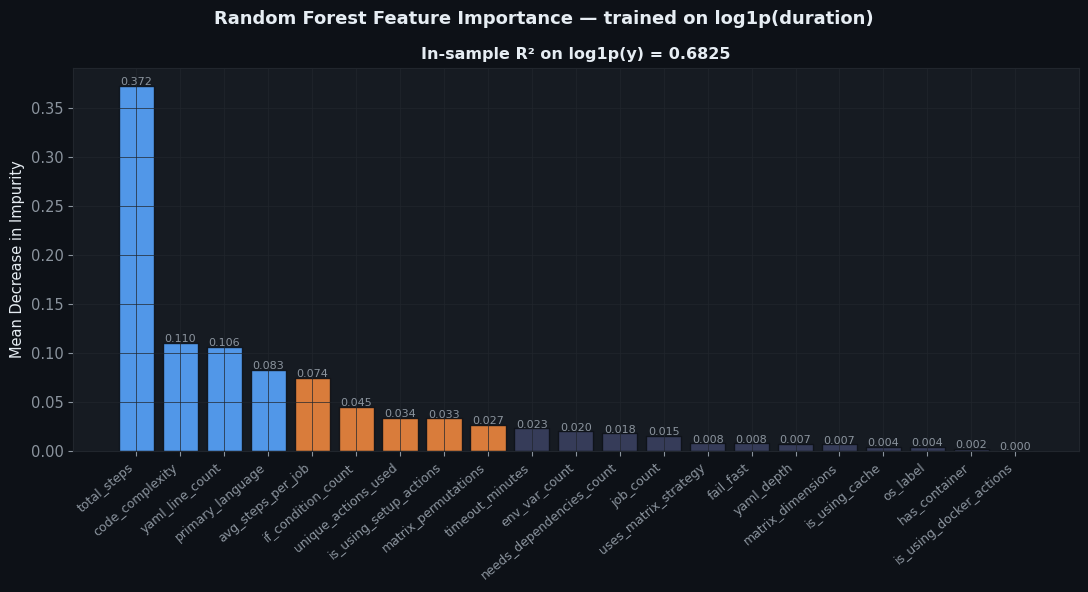

In [14]:
rf_feat_cols = [c for c in all_features if df[c].std()>0]
X_rf = df[rf_feat_cols].astype(float).values
y_rf = np.log1p(df[TARGET].values)

np.random.seed(42)
rf = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=3,
                            random_state=42, n_jobs=-1)
rf.fit(X_rf, y_rf)

rf_imp = (pd.Series(rf.feature_importances_,
                    index=[c.replace('_enc','') for c in rf_feat_cols])
          .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle('Random Forest Feature Importance — trained on log1p(duration)')

imp_c = [C[0] if i<4 else C[1] if i<9 else '#3a4060' for i in range(len(rf_imp))]
ax.bar(range(len(rf_imp)), rf_imp.values, color=imp_c, edgecolor=BG, alpha=0.9)
ax.set_xticks(range(len(rf_imp)))
ax.set_xticklabels(rf_imp.index, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Mean Decrease in Impurity')
ax.set_title(f'In-sample R² on log1p(y) = {rf.score(X_rf,y_rf):.4f}')
for i,v in enumerate(rf_imp.values):
    ax.text(i, v+0.001, f'{v:.3f}', ha='center', fontsize=8, color=TICK)

plt.tight_layout(); plt.show()

---
## 14 · Final Feature Ranking — Composite Score

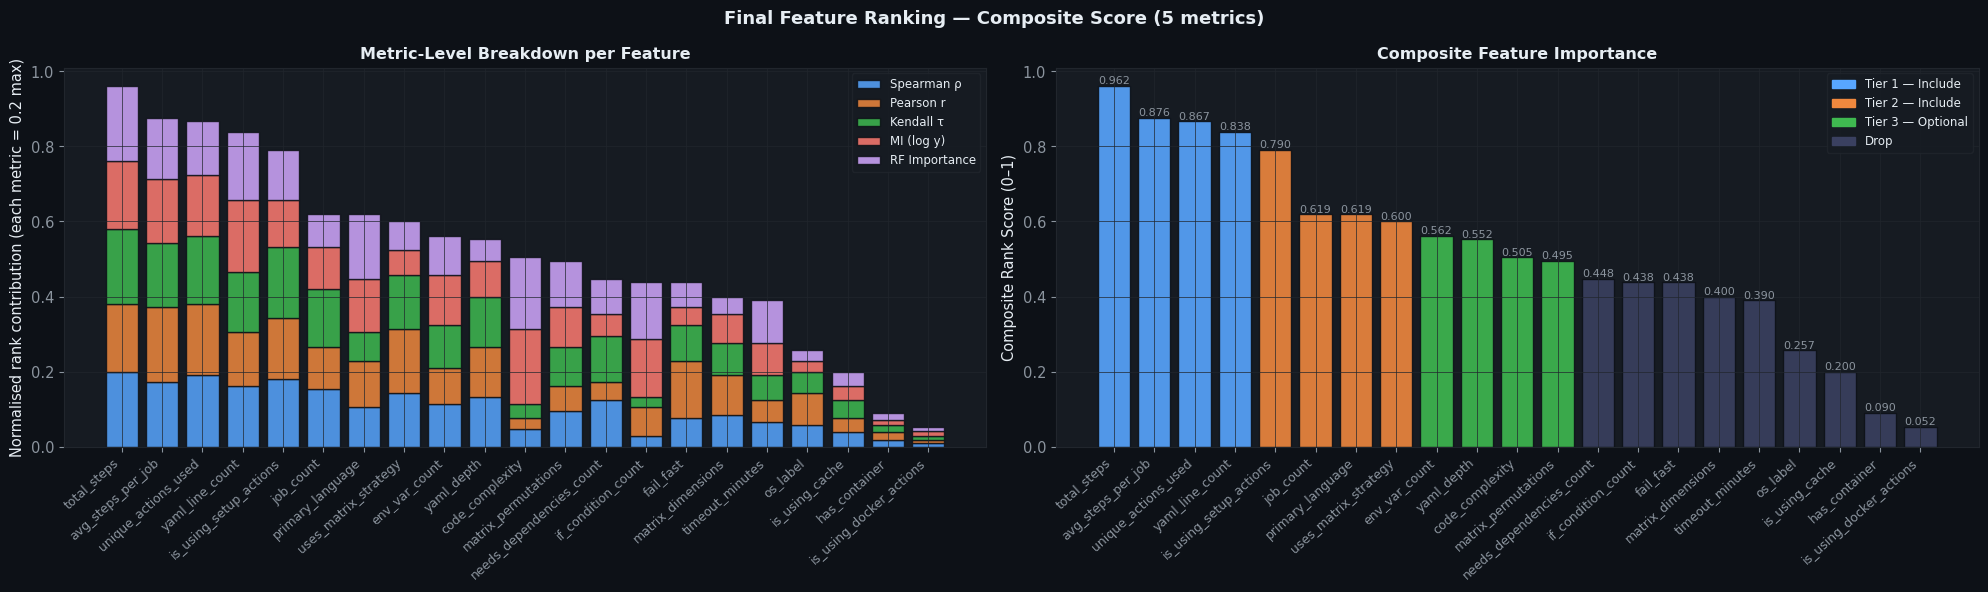


Full composite ranking:


,Feature,|Spearman|,|Pearson|,|Kendall|,MI (log y),RF Imp,Composite
1,total_steps,0.4401,0.2949,0.3288,0.41876,0.37237,0.9619
2,avg_steps_per_job,0.3651,0.3175,0.2730,0.41814,0.07446,0.8762
3,unique_actions_used,0.3806,0.3119,0.2931,0.23838,0.03361,0.8667
4,yaml_line_count,0.3124,0.2481,0.2238,0.42906,0.10640,0.8381
5,is_using_setup_actions,0.3745,0.2702,0.3083,0.13323,0.03334,0.7905
6,job_count,0.2789,0.2034,0.2200,0.11414,0.01504,0.6190
7,primary_language,0.2251,0.2173,0.1609,0.15343,0.08280,0.6190
8,uses_matrix_strategy,0.2541,0.2922,0.2092,0.06668,0.00777,0.6000
9,env_var_count,0.2271,0.1949,0.1707,0.14748,0.01994,0.5619
10,yaml_depth,0.2333,0.2372,0.1890,0.08021,0.00744,0.5524


In [15]:
def rank_norm(series):
    r = series.abs().rank(ascending=True)
    return (r / len(r)).round(4)

rank_df = corr_df.copy()
rank_df['RF Imp'] = rank_df['Feature'].map(rf_imp.to_dict()).fillna(0)

for col in ['|Spearman|','|Pearson|','|Kendall|','MI (log y)','RF Imp']:
    rank_df[f'R_{col}'] = rank_norm(rank_df[col])

r_cols = [c for c in rank_df.columns if c.startswith('R_')]
rank_df['Composite'] = rank_df[r_cols].mean(axis=1)
rank_df = rank_df.sort_values('Composite', ascending=False).reset_index(drop=True)
rank_df.index += 1

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Final Feature Ranking — Composite Score (5 metrics)')

# Stacked metric contribution
ax = axes[0]
metrics_display = ['R_|Spearman|','R_|Pearson|','R_|Kendall|','R_MI (log y)','R_RF Imp']
labels_display  = ['Spearman ρ','Pearson r','Kendall τ','MI (log y)','RF Importance']
bottoms = np.zeros(len(rank_df))
for metric, label, color in zip(metrics_display, labels_display, C):
    vals = rank_df[metric].values / 5
    ax.bar(range(len(rank_df)), vals, bottom=bottoms, color=color,
           alpha=0.85, edgecolor=BG, label=label)
    bottoms += vals
ax.set_xticks(range(len(rank_df)))
ax.set_xticklabels(rank_df['Feature'], rotation=42, ha='right', fontsize=9)
ax.set_ylabel('Normalised rank contribution (each metric = 0.2 max)')
ax.set_title('Metric-Level Breakdown per Feature')
ax.legend(fontsize=8.5, loc='upper right')

# Composite score bar with tier shading
ax = axes[1]
tier_c = [C[0] if i<4 else C[1] if i<8 else C[2] if i<12 else '#3a4060'
           for i in range(len(rank_df))]
ax.bar(range(len(rank_df)), rank_df['Composite'], color=tier_c, edgecolor=BG, alpha=0.9)
ax.set_xticks(range(len(rank_df)))
ax.set_xticklabels(rank_df['Feature'], rotation=42, ha='right', fontsize=9)
ax.set_ylabel('Composite Rank Score (0–1)')
ax.set_title('Composite Feature Importance')
for i,v in enumerate(rank_df['Composite']):
    ax.text(i, v+0.005, f'{v:.3f}', ha='center', fontsize=8, color=TICK)

# Tier legends
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=C[0],label='Tier 1 — Include'),
                   Patch(color=C[1],label='Tier 2 — Include'),
                   Patch(color=C[2],label='Tier 3 — Optional'),
                   Patch(color='#3a4060',label='Drop')],
          fontsize=8.5, loc='upper right')

plt.tight_layout(); plt.show()

print('\nFull composite ranking:')
display(rank_df[['Feature','|Spearman|','|Pearson|','|Kendall|',
                  'MI (log y)','RF Imp','Composite']]
        .style.bar(subset=['Composite'], color=C[0])
        .format({'|Spearman|':'{:.4f}','|Pearson|':'{:.4f}','|Kendall|':'{:.4f}',
                 'MI (log y)':'{:.5f}','RF Imp':'{:.5f}','Composite':'{:.4f}'}))

---
## 15 · EDA Summary, Feature Selection & Model Recommendation

In [16]:
print('═══ KEY EDA FINDINGS ════════════════════════════════════════════════════')
print()
print('Dataset')
print(f'  {len(df_raw)} rows · {df_raw["repo_name"].nunique()} repos · {df_raw["workflow_name"].nunique()} unique workflow names')
print(f'  Outliers removed: {len(outliers)} ({len(outliers)/len(df_raw)*100:.1f}%) — duration > {hi:.2f} min')
print(f'  Clean dataset: {len(df)} rows')
print()
print('Target (duration_minutes)')
print(f'  Highly right-skewed (skew={clean_t.skew():.2f}) — raw target is NOT normal')
print(f'  log1p(y) reduces skew to {log_t.skew():.2f} and approximates normality better')
print(f'  242 zero-duration rows retained (failed/instant workflow runs)')
print()
print('Strongest predictors (by Spearman ρ on clean data):')
for _, row in rank_df.head(8).iterrows():
    print(f'  #{int(row.name):>2}  {row["Feature"]:<35} ρ={row["|Spearman|"]:.4f}  MI={row["MI (log y)"]:.5f}')
print()
print('Collinear pairs to address before linear models:')
collinear_groups = [
    ('matrix_dimensions', 'uses_matrix_strategy', 'matrix_permutations',
     '→ keep matrix_permutations only (most granular, r=0.89 with others)'),
    ('total_steps', 'avg_steps_per_job',
     '→ high collinearity (r=0.86). Keep avg_steps_per_job for linear; both for trees'),
    ('total_steps', 'unique_actions_used',
     '→ r=0.72. Trees handle; for Ridge/Lasso, drop one'),
    ('job_count', 'needs_dependencies_count',
     '→ r=0.69. Logical: more jobs → more needs. Keep both for trees'),
]
for g in collinear_groups:
    print('  ' + '  /  '.join(g[:-1]) + '  ' + g[-1])

═══ KEY EDA FINDINGS ════════════════════════════════════════════════════

Dataset
  4115 rows · 126 repos · 650 unique workflow names
  Outliers removed: 583 (14.2%) — duration > 10.93 min
  Clean dataset: 3532 rows

Target (duration_minutes)
  Highly right-skewed (skew=1.90) — raw target is NOT normal
  log1p(y) reduces skew to 0.94 and approximates normality better
  242 zero-duration rows retained (failed/instant workflow runs)

Strongest predictors (by Spearman ρ on clean data):
  # 1  total_steps                         ρ=0.4401  MI=0.41876
  # 2  avg_steps_per_job                   ρ=0.3651  MI=0.41814
  # 3  unique_actions_used                 ρ=0.3806  MI=0.23838
  # 4  yaml_line_count                     ρ=0.3124  MI=0.42906
  # 5  is_using_setup_actions              ρ=0.3745  MI=0.13323
  # 6  job_count                           ρ=0.2789  MI=0.11414
  # 7  primary_language                    ρ=0.2251  MI=0.15343
  # 8  uses_matrix_strategy                ρ=0.2541  MI=0.06668

In [17]:
print()
print('═══ COLD-START FEATURE SET ══════════════════════════════════════════════')
print()
print('These features are derivable from the YAML file + static code analysis')
print('for any new repository — no historical run data required.')
print()

include = {
    'TIER 1 — Strong signal (include always)': [
        ('total_steps',          'Spearman ρ=0.44  MI=0.43  — total pipeline work'),
        ('avg_steps_per_job',    'Spearman ρ=0.37  MI=0.43  — per-job workload intensity'),
        ('unique_actions_used',  'Spearman ρ=0.38  MI=0.26  — action diversity / setup overhead'),
        ('yaml_line_count',      'Spearman ρ=0.31  MI=0.51  — overall workflow complexity'),
        ('code_complexity',      'Spearman ρ=0.08  MI=0.55  — non-linear signal; high MI, low linear corr'),
        ('os_label',             'KW p<0.001       MI=0.02  — macos >> windows >> ubuntu; encode by median'),
        ('primary_language',     'KW p<0.001       MI=0.16  — build ecosystem drives duration'),
    ],
    'TIER 2 — Moderate signal (include in full model)': [
        ('yaml_depth',              'Spearman ρ=0.23  MI=0.08  — nesting depth'),
        ('job_count',               'Spearman ρ=0.28  MI=0.10  — parallel job fan-out'),
        ('env_var_count',           'Spearman ρ=0.23  MI=0.15  — configuration density'),
        ('matrix_permutations',     'Spearman ρ=0.21  MI=0.14  — matrix expansion factor'),
        ('needs_dependencies_count','Spearman ρ=0.23  MI=0.08  — sequential job chains'),
        ('uses_matrix_strategy',    'KW p<0.001       MI=0.09  — 2.9 min vs 1.3 min mean'),
        ('is_using_setup_actions',  'KW p<0.001       MI=0.14  — 2.0 min vs 0.6 min mean'),
        ('is_using_cache',          'KW p<0.001       MI=0.03  — longer jobs use cache'),
        ('timeout_minutes',         'Spearman ρ=0.19  MI=0.08  — non-zero = expected long run'),
    ],
    'TIER 3 — Drop (low signal, collinear, or not cold-start)': [
        ('workflow_name',         'NOT cold-start — meaningless for unseen repos'),
        ('matrix_dimensions',     'Collinear with matrix_permutations (ρ=0.88) — drop'),
        ('is_using_docker_actions','KW p=0.84 — no significant duration effect'),
        ('if_condition_count',    'Spearman ρ=0.07 — weak; low MI vs log(y)'),
        ('fail_fast',             'No significant duration effect after removal'),
        ('has_container',         'Only 58 rows; too sparse for reliable signal'),
        ('total_cost_usd',        'LEAKAGE — deterministic function of target'),
        ('repo_name','head_sha',  'Identifiers'),
    ]
}

for tier, feats in include.items():
    print(f'  {tier}')
    for item in feats:
        if isinstance(item, tuple) and len(item)==2:
            print(f'    ✓  {item[0]:<35} {item[1]}')
        else:
            print(f'    ✗  {item}')
    print()


═══ COLD-START FEATURE SET ══════════════════════════════════════════════

These features are derivable from the YAML file + static code analysis
for any new repository — no historical run data required.

  TIER 1 — Strong signal (include always)
    ✓  total_steps                         Spearman ρ=0.44  MI=0.43  — total pipeline work
    ✓  avg_steps_per_job                   Spearman ρ=0.37  MI=0.43  — per-job workload intensity
    ✓  unique_actions_used                 Spearman ρ=0.38  MI=0.26  — action diversity / setup overhead
    ✓  yaml_line_count                     Spearman ρ=0.31  MI=0.51  — overall workflow complexity
    ✓  code_complexity                     Spearman ρ=0.08  MI=0.55  — non-linear signal; high MI, low linear corr
    ✓  os_label                            KW p<0.001       MI=0.02  — macos >> windows >> ubuntu; encode by median
    ✓  primary_language                    KW p<0.001       MI=0.16  — build ecosystem drives duration

  TIER 2 — Moderate sign

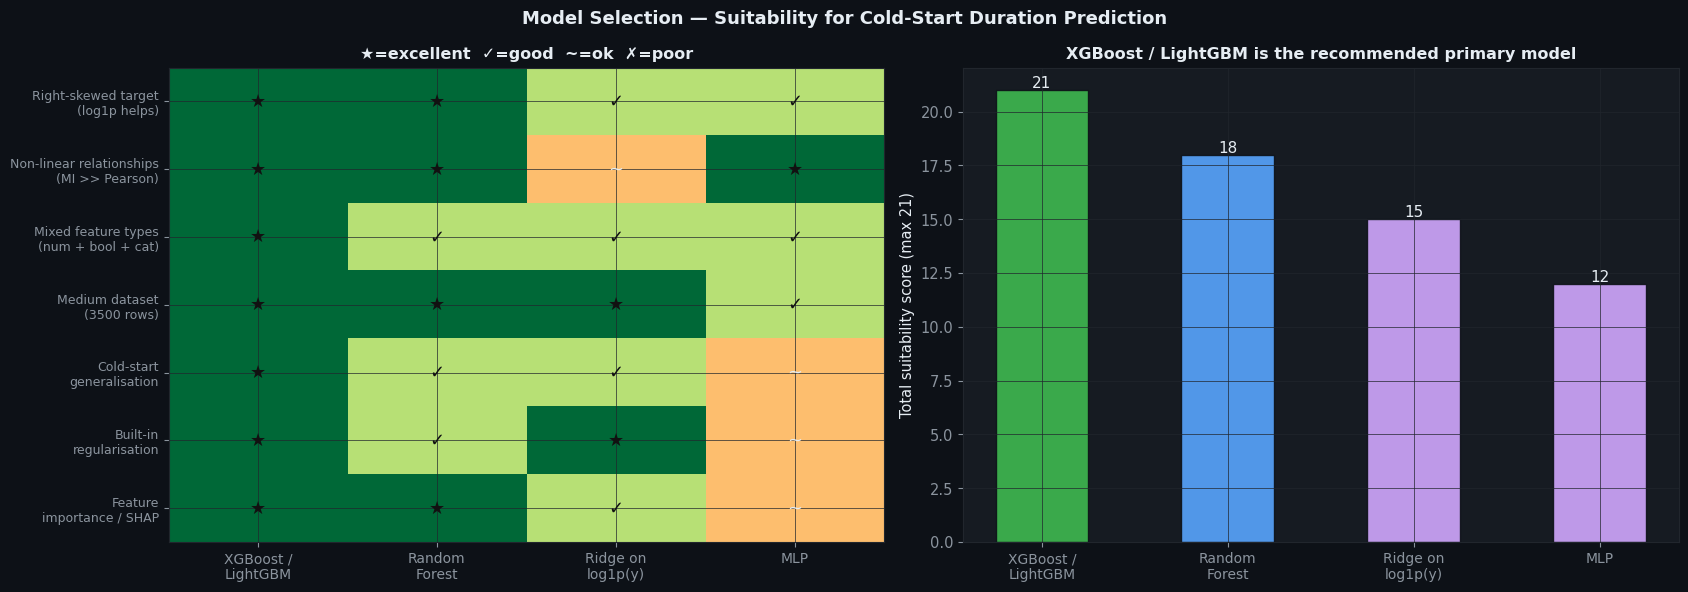


═══ FINAL MODEL RECOMMENDATION ═════════════════════════════════════════

  PRIMARY    XGBoost / LightGBM
             • Target: log1p(duration_minutes)
             • Handles non-linear MI > Pearson features natively
             • Ordinal-encode os_label + primary_language by median duration
             • L1 + L2 regularisation (reg_alpha, reg_lambda) for cold-start

  BASELINE   Random Forest Regressor on log1p(y)

  ABLATION   Ridge Regression on log1p(y) + one-hot encoded categoricals
             Drop one of each collinear pair for stable coefficients

  METRIC     RMSLE  =  sqrt(mean((log(pred+1) - log(true+1))²))
             Symmetric, penalises large relative errors

  VALIDATION GroupKFold(n_splits=5, groups=repo_name)
             Each fold tests on UNSEEN repositories — simulates cold-start
             Never use random split: same repo leaks across train/test

  FEATURES   Tier 1 (7) + Tier 2 (9) = 16 cold-start predictors
═══════════════════════════════════════════════

In [18]:
# ── Model recommendation suitability chart ────────────────────────────────
models   = ['XGBoost /\nLightGBM', 'Random\nForest', 'Ridge on\nlog1p(y)', 'MLP']
criteria = [
    'Right-skewed target\n(log1p helps)',
    'Non-linear relationships\n(MI >> Pearson)',
    'Mixed feature types\n(num + bool + cat)',
    'Medium dataset\n(3500 rows)',
    'Cold-start\ngeneralisation',
    'Built-in\nregularisation',
    'Feature\nimportance / SHAP',
]
# 0=poor 1=ok 2=good 3=excellent
scores = np.array([
    [3, 3, 3, 3, 3, 3, 3],  # XGBoost/LightGBM
    [3, 3, 2, 3, 2, 2, 3],  # RF
    [2, 1, 2, 3, 2, 3, 2],  # Ridge
    [2, 3, 2, 2, 1, 1, 1],  # MLP
])

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Model Selection — Suitability for Cold-Start Duration Prediction')

# Heatmap
ax = axes[0]
im = ax.imshow(scores.T, cmap='RdYlGn', vmin=0, vmax=3, aspect='auto')
ax.set_xticks(range(len(models)));  ax.set_xticklabels(models, fontsize=10)
ax.set_yticks(range(len(criteria))); ax.set_yticklabels(criteria, fontsize=9)
for i in range(len(models)):
    for j in range(len(criteria)):
        ax.text(i,j,['✗','~','✓','★'][scores[i,j]],ha='center',va='center',
                fontsize=13, color='#111' if scores[i,j]>=2 else TEXT)
ax.set_title('★=excellent  ✓=good  ~=ok  ✗=poor')

# Total score bar
ax = axes[1]
totals = scores.sum(axis=1)
bar_c  = [C[2] if i==0 else C[0] if i==1 else C[4] for i in range(len(models))]
ax.bar(range(len(models)), totals, color=bar_c, edgecolor=BG, alpha=0.9, width=0.5)
ax.set_xticks(range(len(models))); ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('Total suitability score (max 21)')
ax.set_title('XGBoost / LightGBM is the recommended primary model')
for i,v in enumerate(totals):
    ax.text(i, v+0.1, str(v), ha='center', fontsize=11, color=TEXT)

plt.tight_layout(); plt.show()

print()
print('═══ FINAL MODEL RECOMMENDATION ═════════════════════════════════════════')
print()
print('  PRIMARY    XGBoost / LightGBM')
print('             • Target: log1p(duration_minutes)')
print('             • Handles non-linear MI > Pearson features natively')
print('             • Ordinal-encode os_label + primary_language by median duration')
print('             • L1 + L2 regularisation (reg_alpha, reg_lambda) for cold-start')
print()
print('  BASELINE   Random Forest Regressor on log1p(y)')
print()
print('  ABLATION   Ridge Regression on log1p(y) + one-hot encoded categoricals')
print('             Drop one of each collinear pair for stable coefficients')
print()
print('  METRIC     RMSLE  =  sqrt(mean((log(pred+1) - log(true+1))²))')
print('             Symmetric, penalises large relative errors')
print()
print('  VALIDATION GroupKFold(n_splits=5, groups=repo_name)')
print('             Each fold tests on UNSEEN repositories — simulates cold-start')
print('             Never use random split: same repo leaks across train/test')
print()
print('  FEATURES   Tier 1 (7) + Tier 2 (9) = 16 cold-start predictors')
print('═════════════════════════════════════════════════════════════════════════')